<a href="https://www.kaggle.com/code/lalit7881/startup-founder-burnout-failure-risk-eda?scriptVersionId=324385294" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohankrishnathalla/startup-founder-burnout-and-failure-risk-dataset/startup_founder_burnout_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mohankrishnathalla/startup-founder-burnout-and-failure-risk-dataset/startup_founder_burnout_2026.csv")

In [3]:
df.head()

,Founder_Type,Economic_Climate,Founder_Age,Founder_Experience_Years,Industry,Funding_Stage,Work_Mode,Team_Size,Startup_Age_Months,Weekly_Work_Hours,...,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Seeks_Mental_Health_Support,Shutdown_Probability,Shutdown_Risk,Startup_Failure_Flag
0,Serial Entrepreneur,Recession,31,12,E-commerce,Seed,Remote,14,99,48.5,...,0,-5.1,5.6,7.8,30.0,9.7,No,0.082,Low,0
1,Calm Operator,Recession,30,0,FinTech,Bootstrapped,Remote,6,47,48.6,...,0,2.7,8.4,2.3,14.4,10.0,No,0.490,Medium,0
2,Burned-Out Operator,Stable Economy,28,3,ClimateTech,Bootstrapped,Hybrid,5,59,68.8,...,0,16.3,4.4,1.0,41.5,4.0,No,0.905,High,1
3,Chaotic Innovator,Stable Economy,32,2,EdTech,Series A,Office,74,143,81.5,...,0,-1.4,31.5,4.0,39.4,5.1,No,0.233,Low,0
4,Growth Obsessed Founder,Stable Economy,35,1,SaaS,Pre-Seed,Hybrid,9,11,78.6,...,0,21.6,7.0,5.2,36.5,4.2,No,0.716,High,1


In [4]:
df.tail()

,Founder_Type,Economic_Climate,Founder_Age,Founder_Experience_Years,Industry,Funding_Stage,Work_Mode,Team_Size,Startup_Age_Months,Weekly_Work_Hours,...,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Seeks_Mental_Health_Support,Shutdown_Probability,Shutdown_Risk,Startup_Failure_Flag
49995,Calm Operator,Stable Economy,29,2,Gaming,Seed,Office,15,124,39.1,...,0,12.6,13.2,8.1,34.9,10.0,No,0.070,Low,0
49996,Serial Entrepreneur,Stable Economy,30,8,E-commerce,Pre-Seed,Hybrid,8,112,44.2,...,0,11.6,18.8,5.7,29.6,9.9,No,0.170,Low,0
49997,Technical Builder,Stable Economy,34,2,ClimateTech,Seed,Office,26,134,71.5,...,0,-4.0,11.4,6.4,49.1,7.3,No,0.319,Low,0
49998,Burned-Out Operator,Stable Economy,42,3,EdTech,Bootstrapped,Remote,6,64,63.3,...,0,0.1,8.6,3.5,36.2,2.1,No,0.875,High,1
49999,Serial Entrepreneur,Bull Market,37,6,FinTech,Pre-Seed,Hybrid,4,68,57.7,...,0,2.4,6.7,5.0,10.9,9.5,Yes,0.283,Low,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Founder_Type                    50000 non-null  object 
 1   Economic_Climate                50000 non-null  object 
 2   Founder_Age                     50000 non-null  int64  
 3   Founder_Experience_Years        50000 non-null  int64  
 4   Industry                        50000 non-null  object 
 5   Funding_Stage                   50000 non-null  object 
 6   Work_Mode                       50000 non-null  object 
 7   Team_Size                       50000 non-null  int64  
 8   Startup_Age_Months              50000 non-null  int64  
 9   Weekly_Work_Hours               50000 non-null  float64
 10  Sleep_Hours                     50000 non-null  float64
 11  Exercise_Days_Per_Week          50000 non-null  float64
 12  Vacation_Days_Taken             

In [6]:
df.dtypes

Founder_Type                       object
Economic_Climate                   object
Founder_Age                         int64
Founder_Experience_Years            int64
Industry                           object
Funding_Stage                      object
Work_Mode                          object
Team_Size                           int64
Startup_Age_Months                  int64
Weekly_Work_Hours                 float64
Sleep_Hours                       float64
Exercise_Days_Per_Week            float64
Vacation_Days_Taken               float64
Investor_Pressure_Score           float64
Cofounder_Conflict_Score          float64
Stress_Score                      float64
Decision_Fatigue_Score            float64
Burnout_Score                     float64
Burnout_Level                      object
Founder_Burnout_Flag                int64
Monthly_Revenue_Growth_Percent    float64
Runway_Months_Remaining           float64
Product_Market_Fit_Score          float64
Employee_Turnover_Percent         

In [7]:
df.shape

(50000, 29)

In [8]:
df.isnull()

,Founder_Type,Economic_Climate,Founder_Age,Founder_Experience_Years,Industry,Funding_Stage,Work_Mode,Team_Size,Startup_Age_Months,Weekly_Work_Hours,...,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Seeks_Mental_Health_Support,Shutdown_Probability,Shutdown_Risk,Startup_Failure_Flag
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

Founder_Type                      0
Economic_Climate                  0
Founder_Age                       0
Founder_Experience_Years          0
Industry                          0
Funding_Stage                     0
Work_Mode                         0
Team_Size                         0
Startup_Age_Months                0
Weekly_Work_Hours                 0
Sleep_Hours                       0
Exercise_Days_Per_Week            0
Vacation_Days_Taken               0
Investor_Pressure_Score           0
Cofounder_Conflict_Score          0
Stress_Score                      0
Decision_Fatigue_Score            0
Burnout_Score                     0
Burnout_Level                     0
Founder_Burnout_Flag              0
Monthly_Revenue_Growth_Percent    0
Runway_Months_Remaining           0
Product_Market_Fit_Score          0
Employee_Turnover_Percent         0
Work_Life_Balance_Score           0
Seeks_Mental_Health_Support       0
Shutdown_Probability              0
Shutdown_Risk               

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

Founder_Type                       object
Economic_Climate                   object
Founder_Age                         int64
Founder_Experience_Years            int64
Industry                           object
Funding_Stage                      object
Work_Mode                          object
Team_Size                           int64
Startup_Age_Months                  int64
Weekly_Work_Hours                 float64
Sleep_Hours                       float64
Exercise_Days_Per_Week            float64
Vacation_Days_Taken               float64
Investor_Pressure_Score           float64
Cofounder_Conflict_Score          float64
Stress_Score                      float64
Decision_Fatigue_Score            float64
Burnout_Score                     float64
Burnout_Level                      object
Founder_Burnout_Flag                int64
Monthly_Revenue_Growth_Percent    float64
Runway_Months_Remaining           float64
Product_Market_Fit_Score          float64
Employee_Turnover_Percent         

In [12]:
df.shape

(50000, 29)

In [13]:
df.columns

Index(['Founder_Type', 'Economic_Climate', 'Founder_Age',
       'Founder_Experience_Years', 'Industry', 'Funding_Stage', 'Work_Mode',
       'Team_Size', 'Startup_Age_Months', 'Weekly_Work_Hours', 'Sleep_Hours',
       'Exercise_Days_Per_Week', 'Vacation_Days_Taken',
       'Investor_Pressure_Score', 'Cofounder_Conflict_Score', 'Stress_Score',
       'Decision_Fatigue_Score', 'Burnout_Score', 'Burnout_Level',
       'Founder_Burnout_Flag', 'Monthly_Revenue_Growth_Percent',
       'Runway_Months_Remaining', 'Product_Market_Fit_Score',
       'Employee_Turnover_Percent', 'Work_Life_Balance_Score',
       'Seeks_Mental_Health_Support', 'Shutdown_Probability', 'Shutdown_Risk',
       'Startup_Failure_Flag'],
      dtype='object')

In [14]:
df.nunique()

Founder_Type                        8
Economic_Climate                    4
Founder_Age                        41
Founder_Experience_Years           13
Industry                           10
Funding_Stage                       6
Work_Mode                           3
Team_Size                         780
Startup_Age_Months                142
Weekly_Work_Hours                 786
Sleep_Hours                        63
Exercise_Days_Per_Week             71
Vacation_Days_Taken               333
Investor_Pressure_Score            91
Cofounder_Conflict_Score          101
Stress_Score                       91
Decision_Fatigue_Score             91
Burnout_Score                      91
Burnout_Level                       3
Founder_Burnout_Flag                2
Monthly_Revenue_Growth_Percent    985
Runway_Months_Remaining           339
Product_Market_Fit_Score           91
Employee_Turnover_Percent         907
Work_Life_Balance_Score            91
Seeks_Mental_Health_Support         2
Shutdown_Pro

## EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Founder_Type                    50000 non-null  object 
 1   Economic_Climate                50000 non-null  object 
 2   Founder_Age                     50000 non-null  int64  
 3   Founder_Experience_Years        50000 non-null  int64  
 4   Industry                        50000 non-null  object 
 5   Funding_Stage                   50000 non-null  object 
 6   Work_Mode                       50000 non-null  object 
 7   Team_Size                       50000 non-null  int64  
 8   Startup_Age_Months              50000 non-null  int64  
 9   Weekly_Work_Hours               50000 non-null  float64
 10  Sleep_Hours                     50000 non-null  float64
 11  Exercise_Days_Per_Week          50000 non-null  float64
 12  Vacation_Days_Taken             

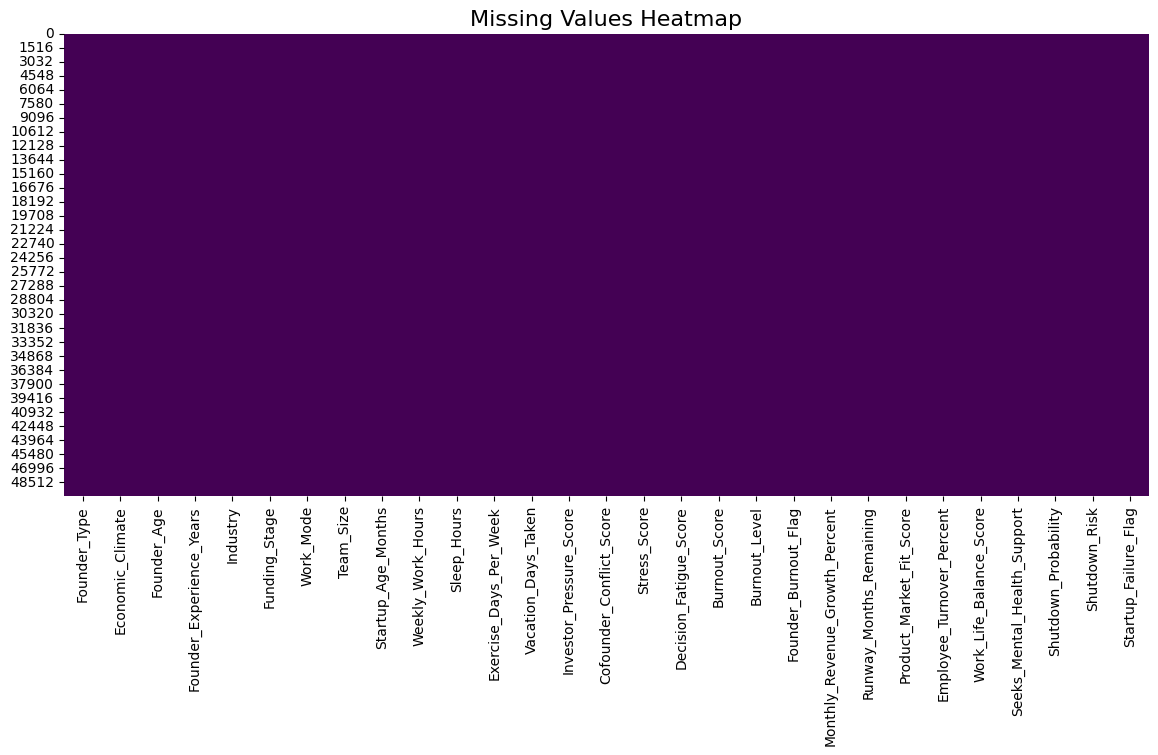

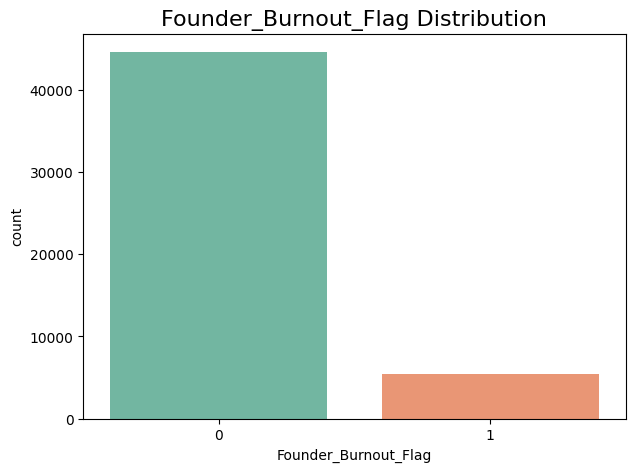

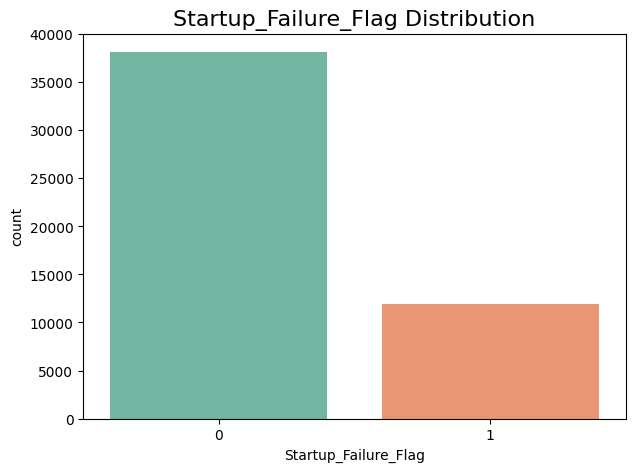

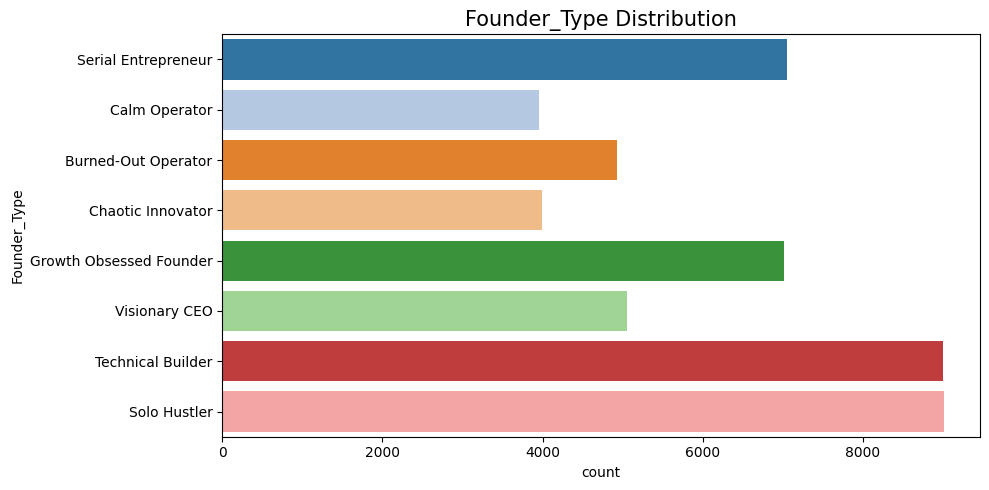

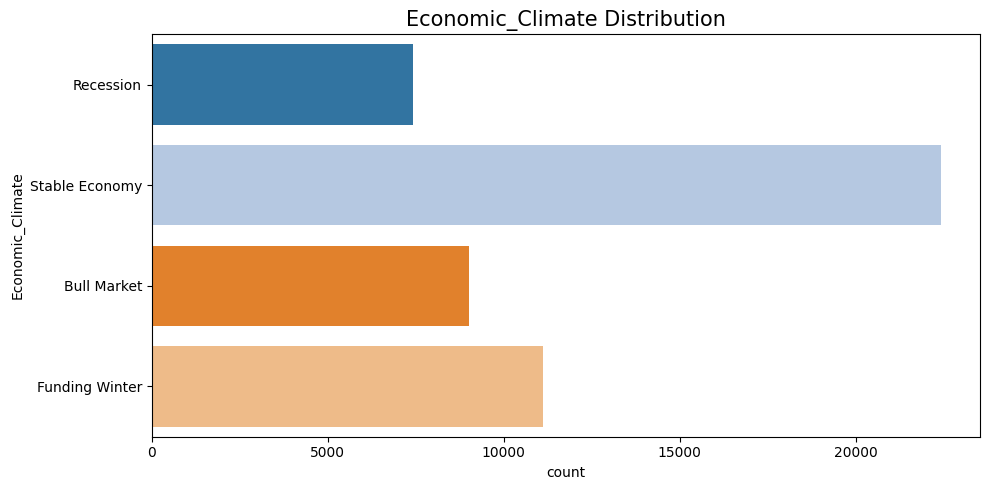

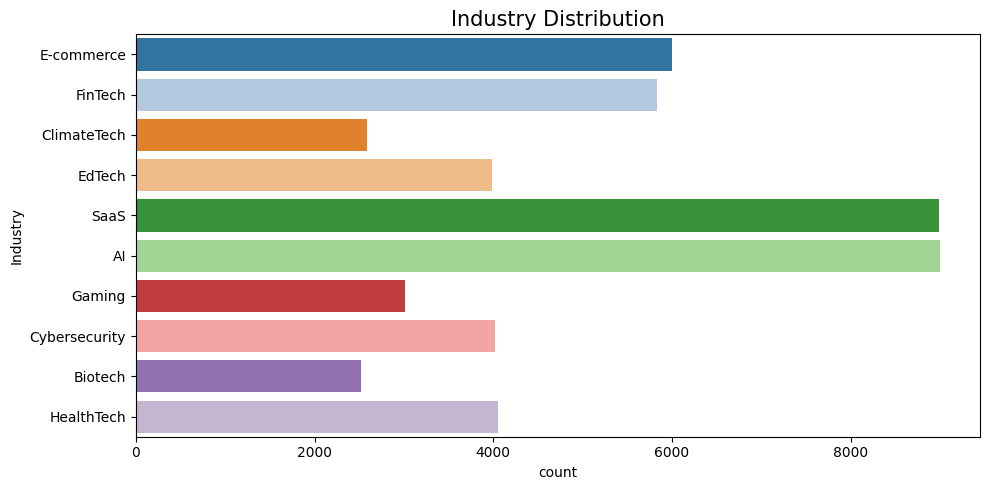

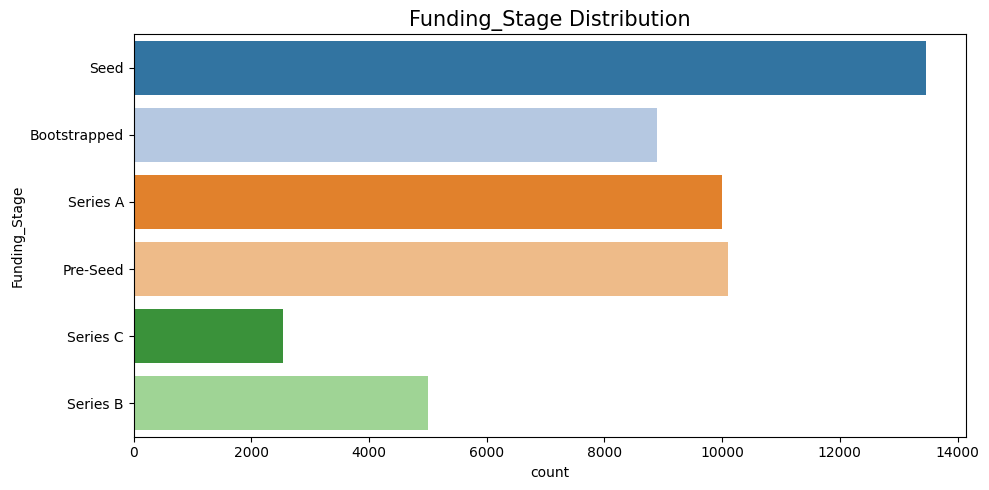

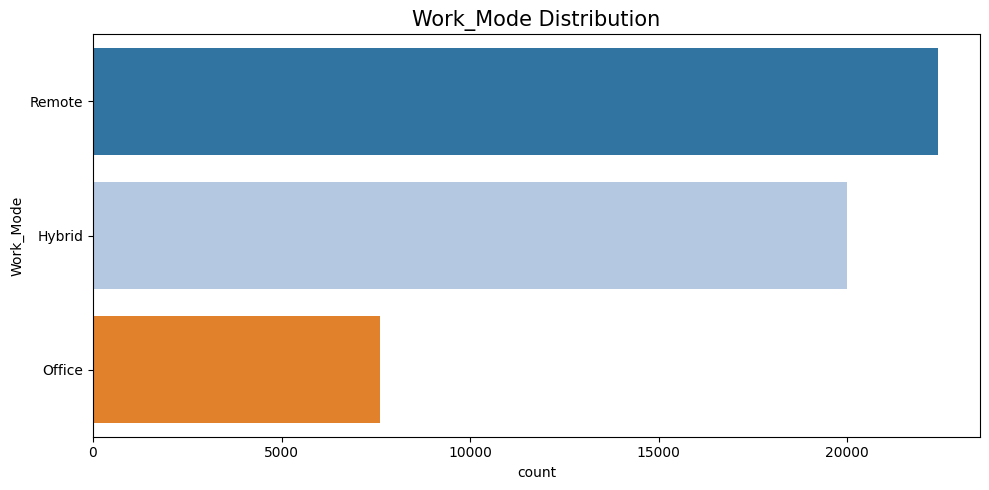

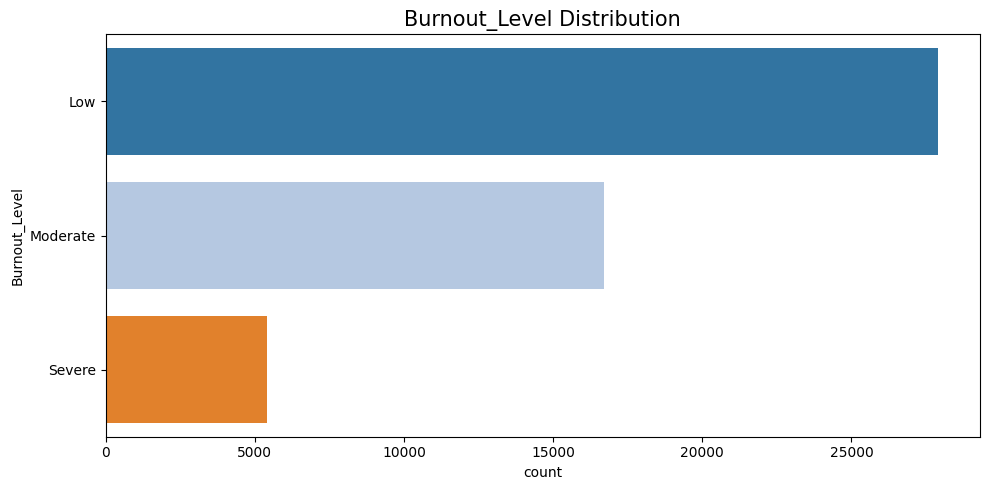

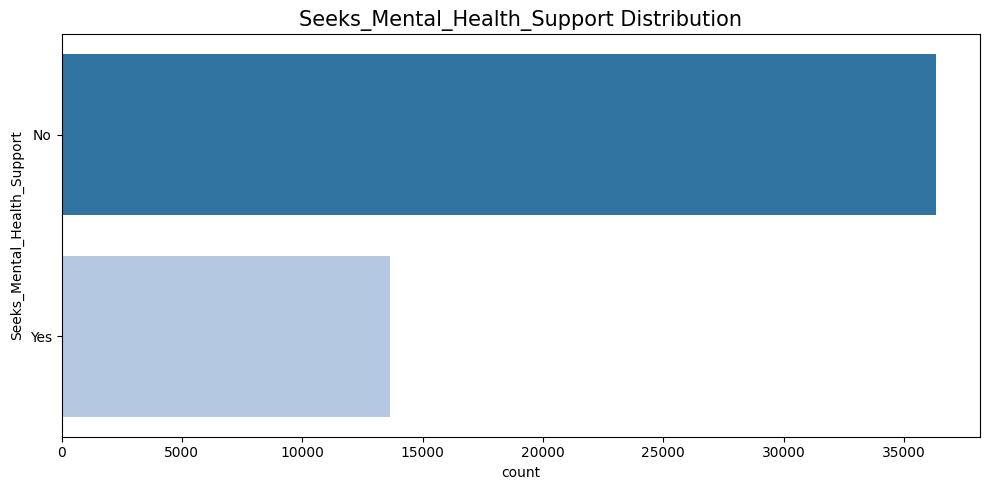

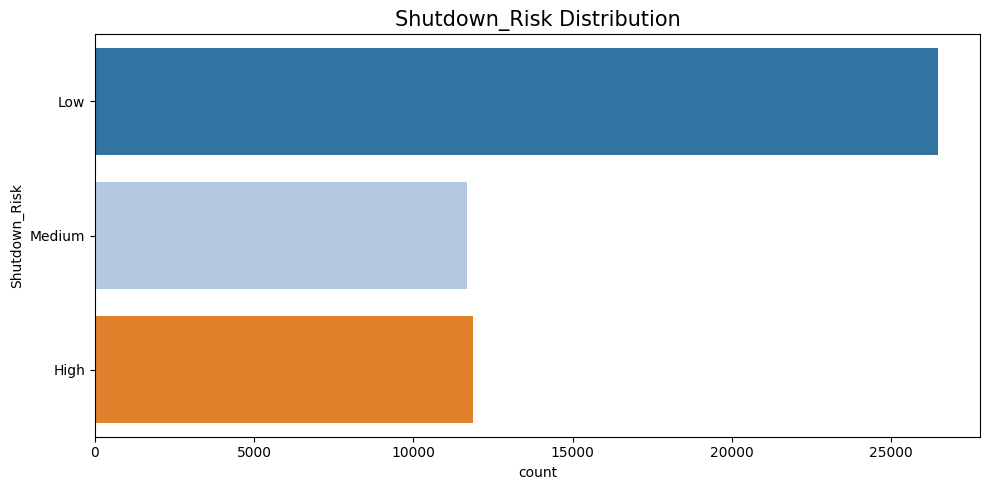

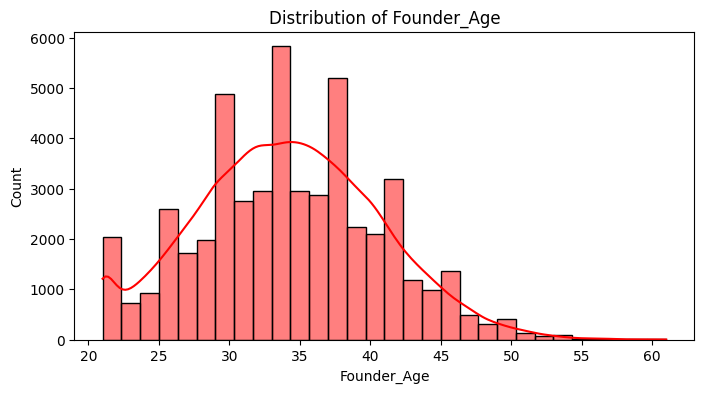

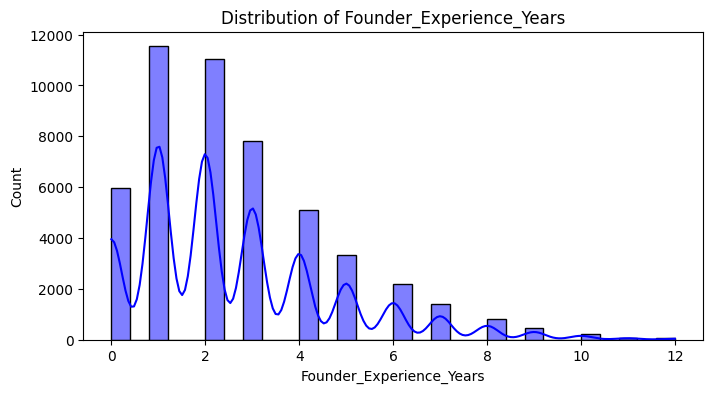

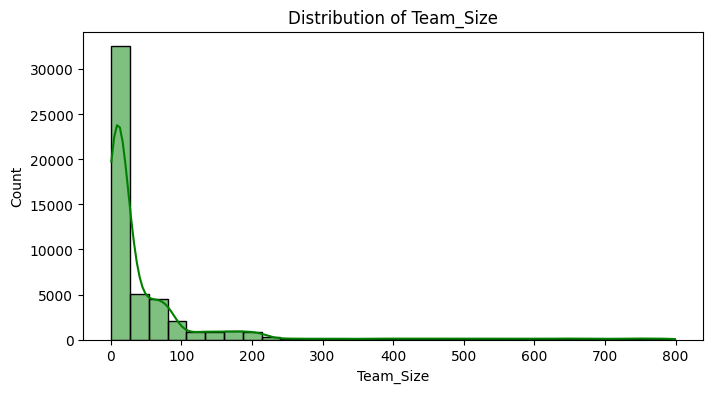

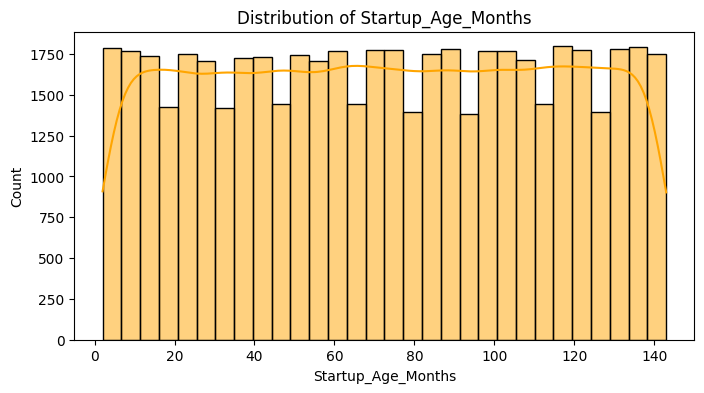

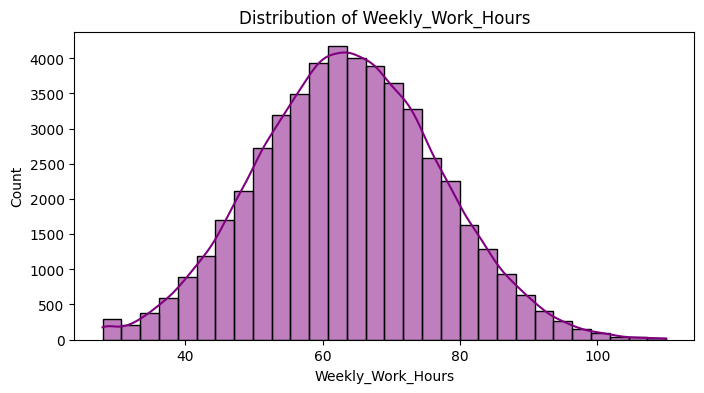

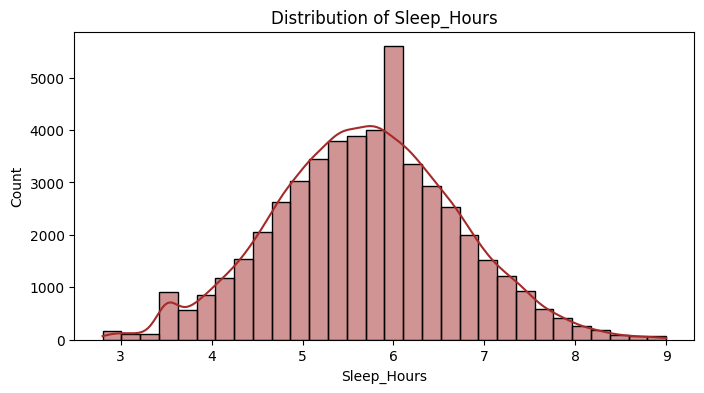

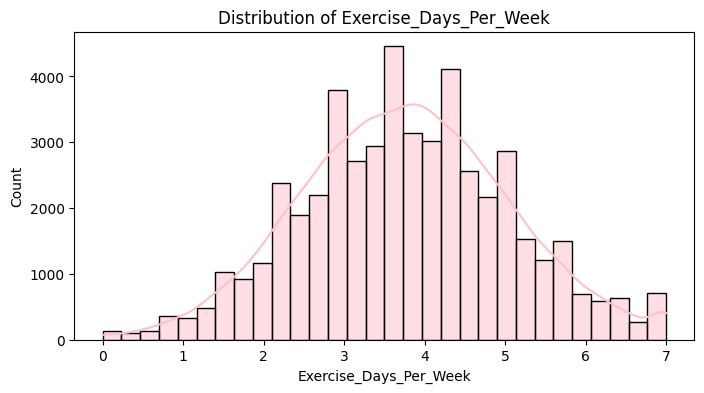

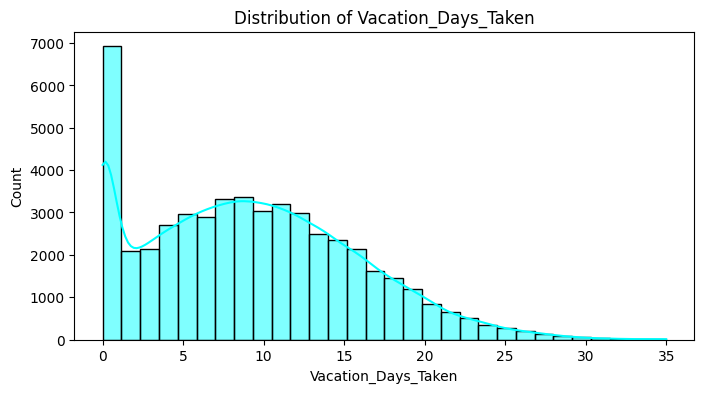

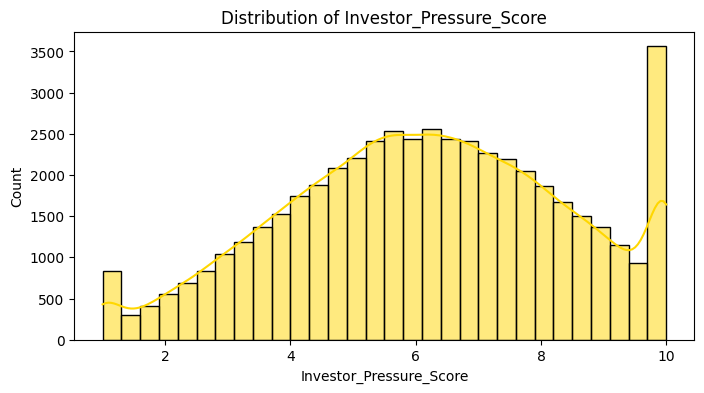

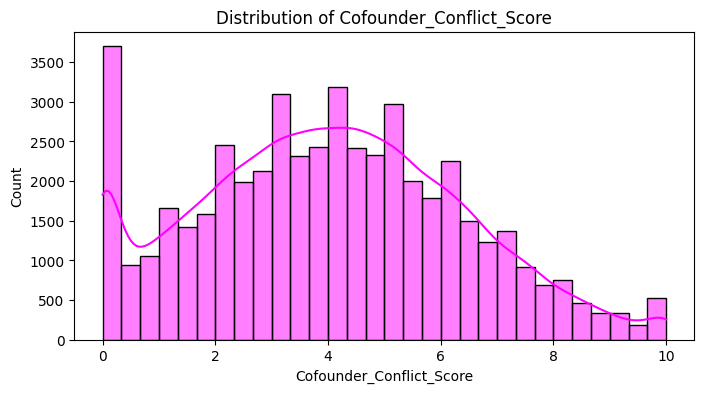

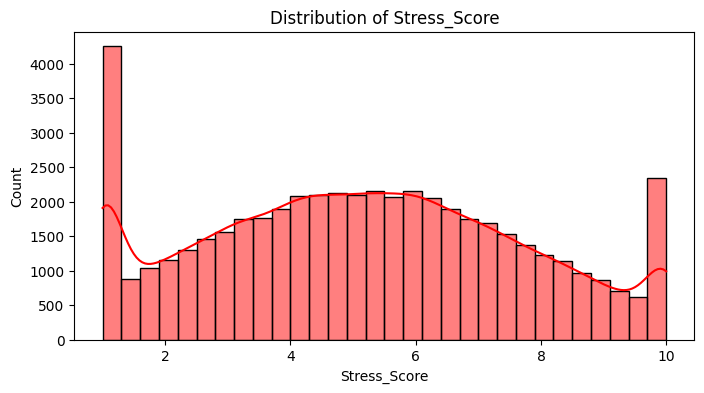

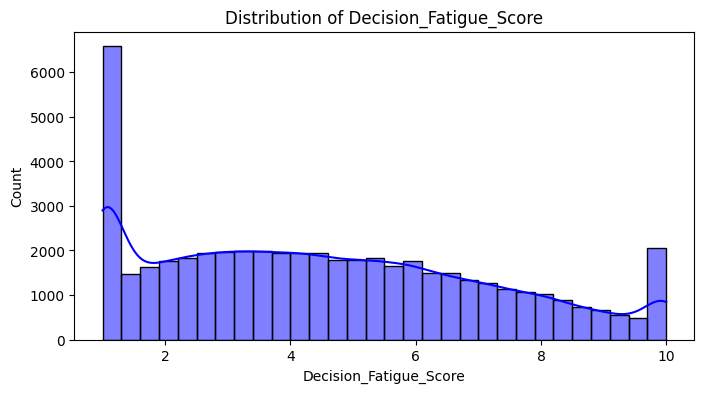

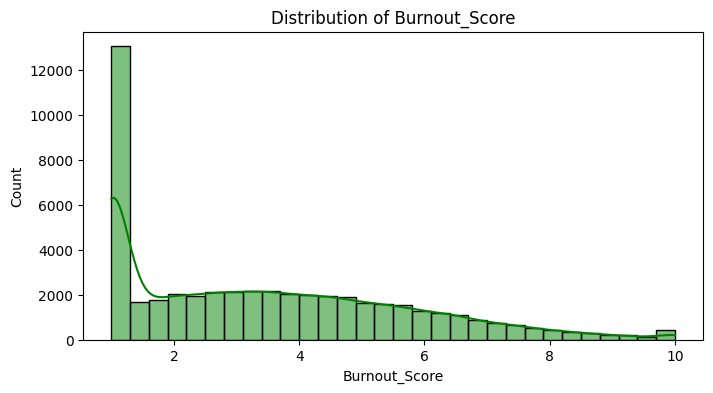

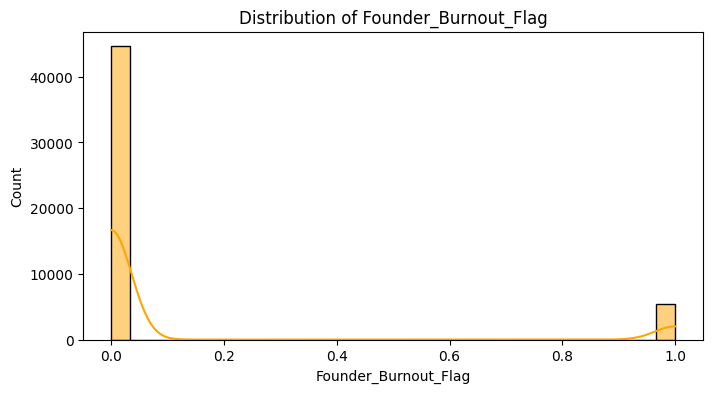

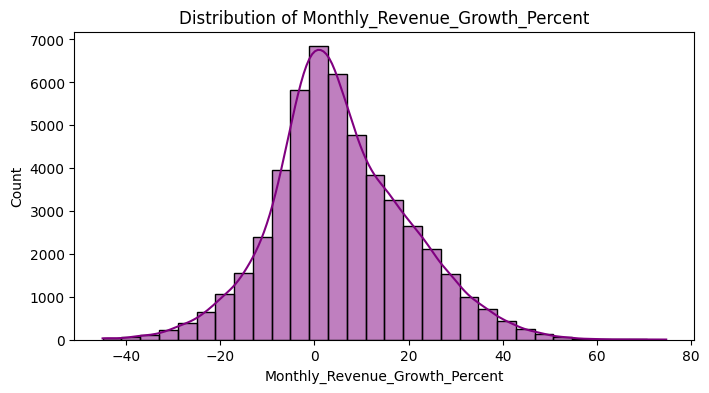

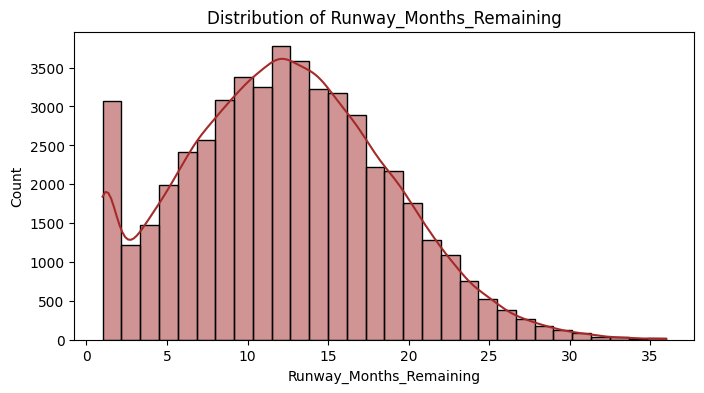

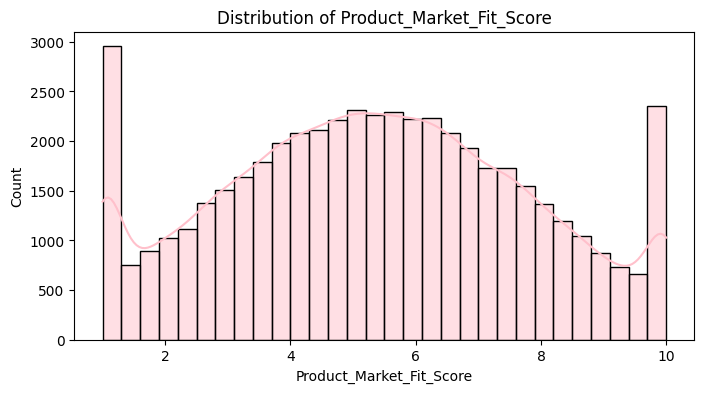

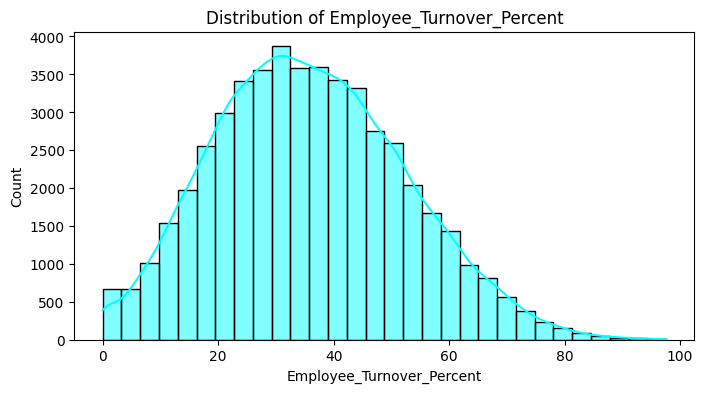

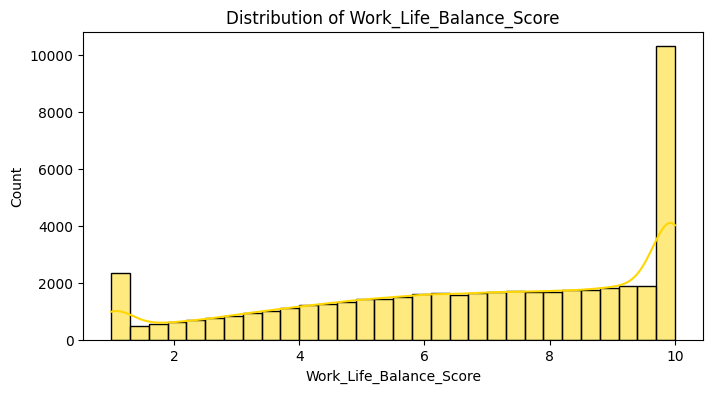

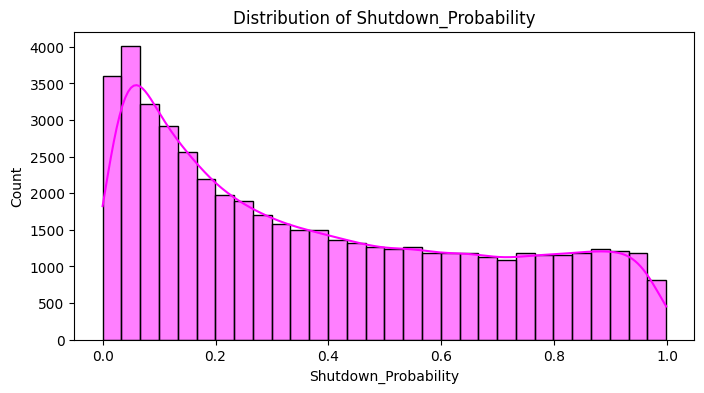

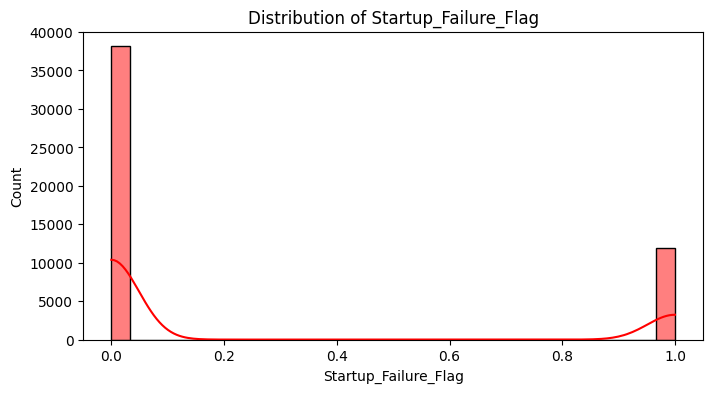

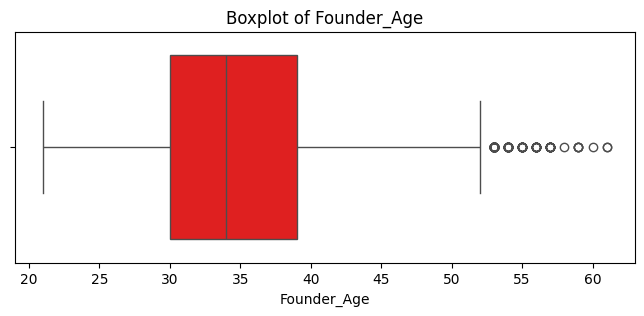

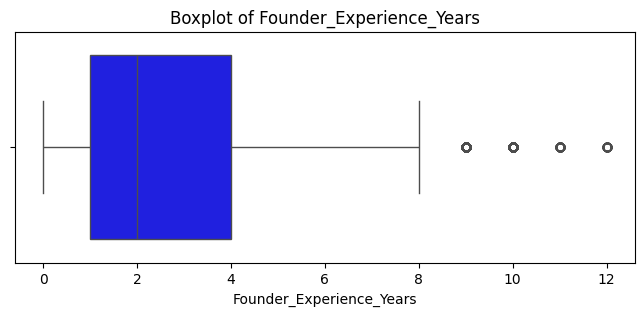

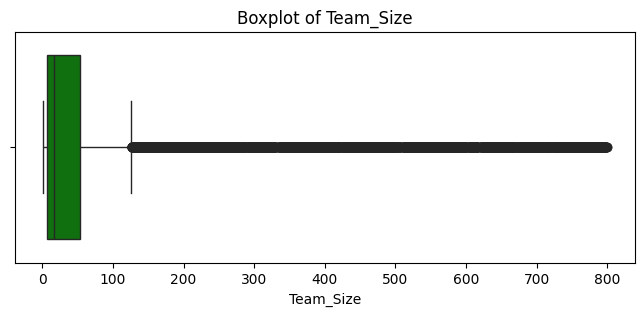

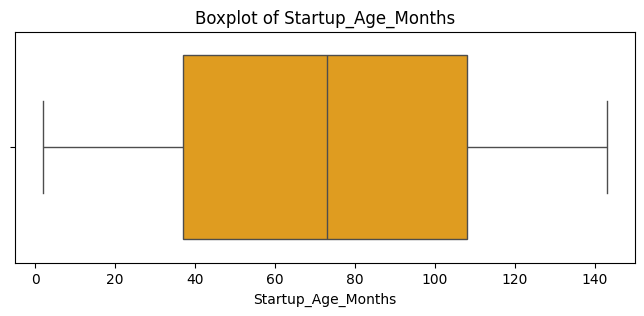

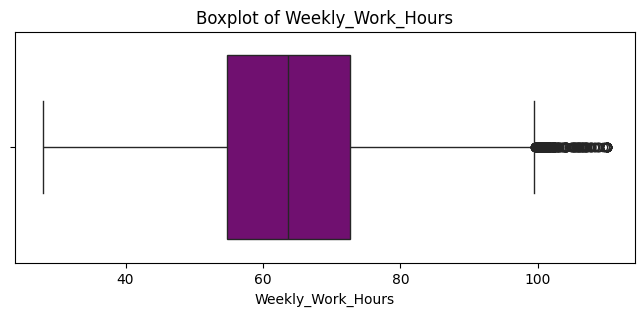

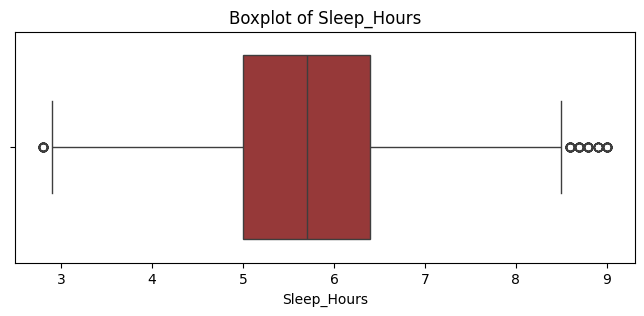

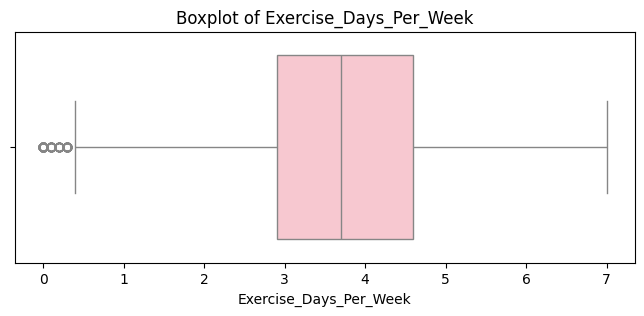

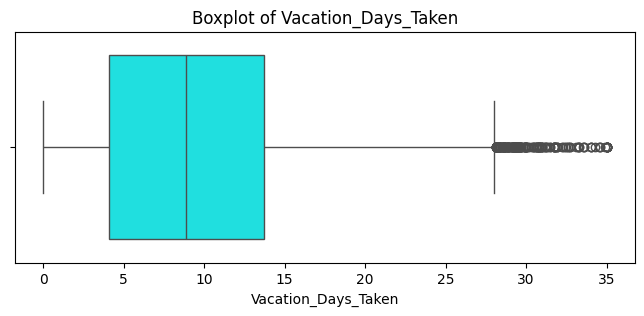

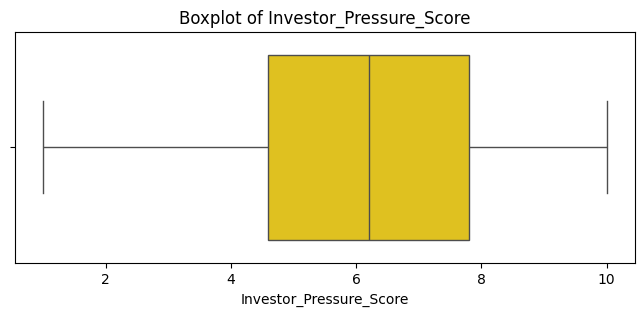

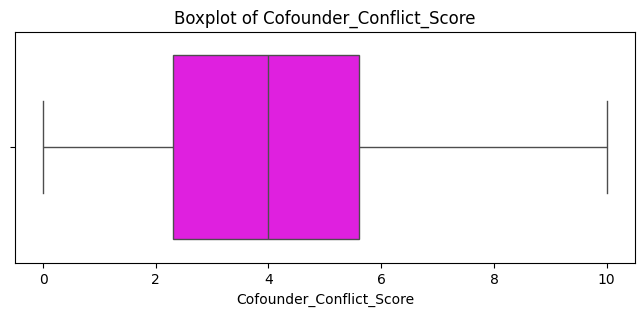

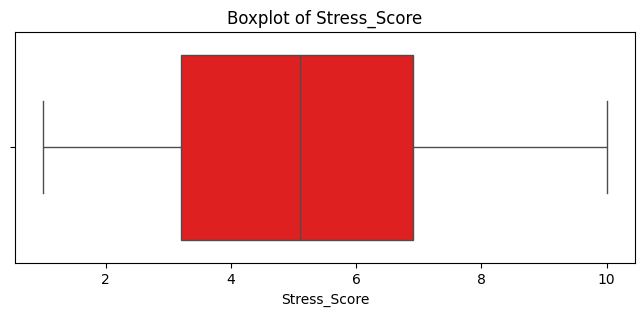

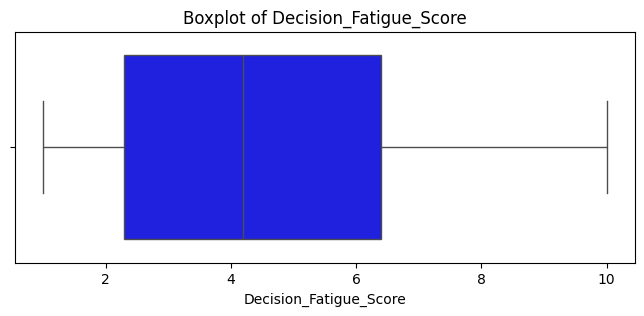

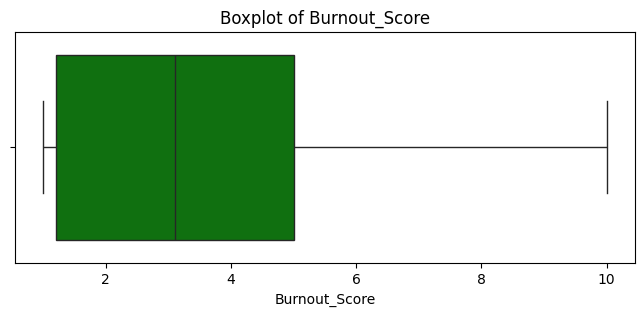

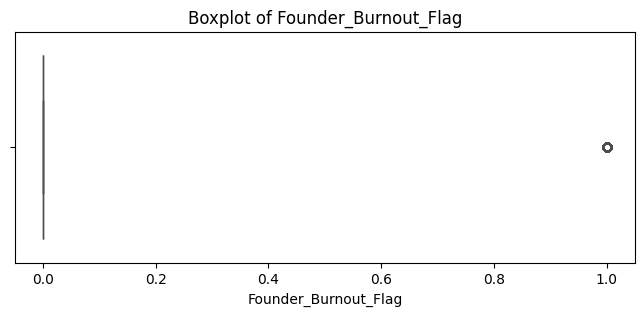

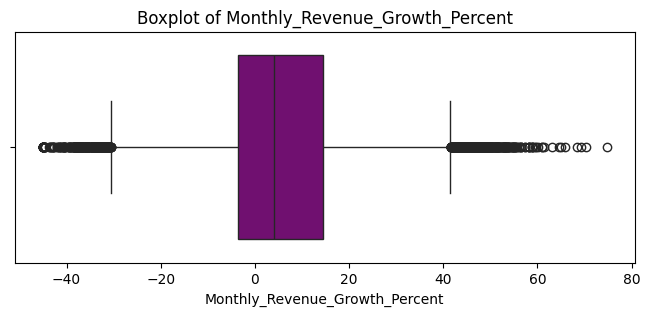

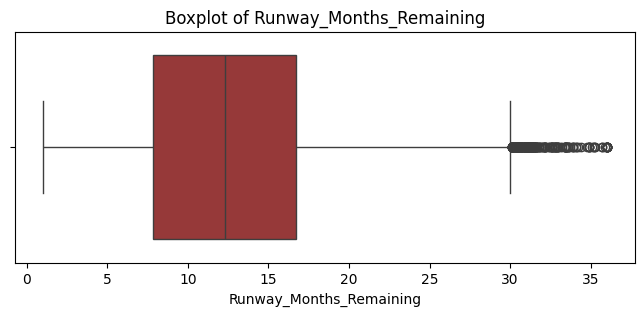

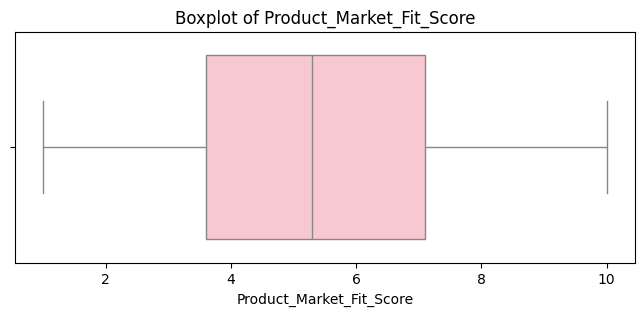

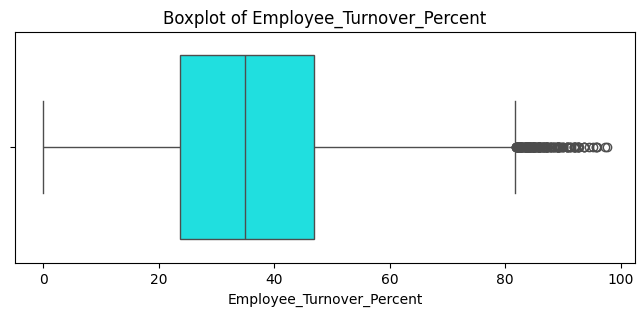

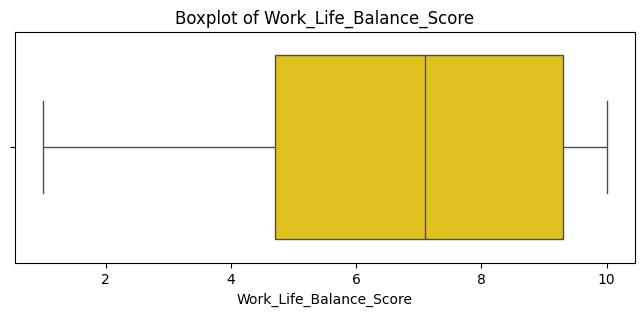

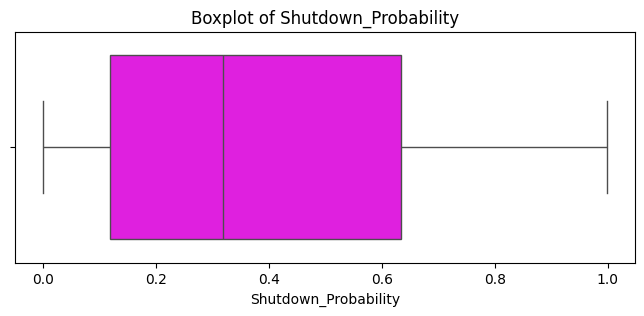

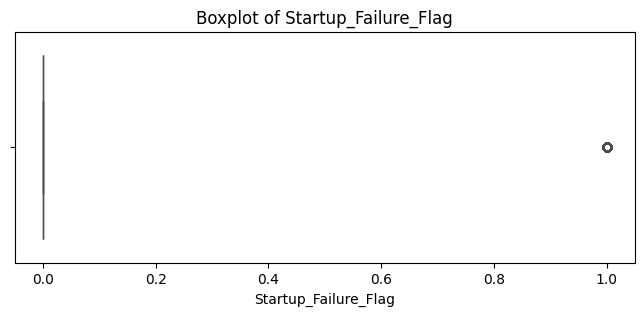

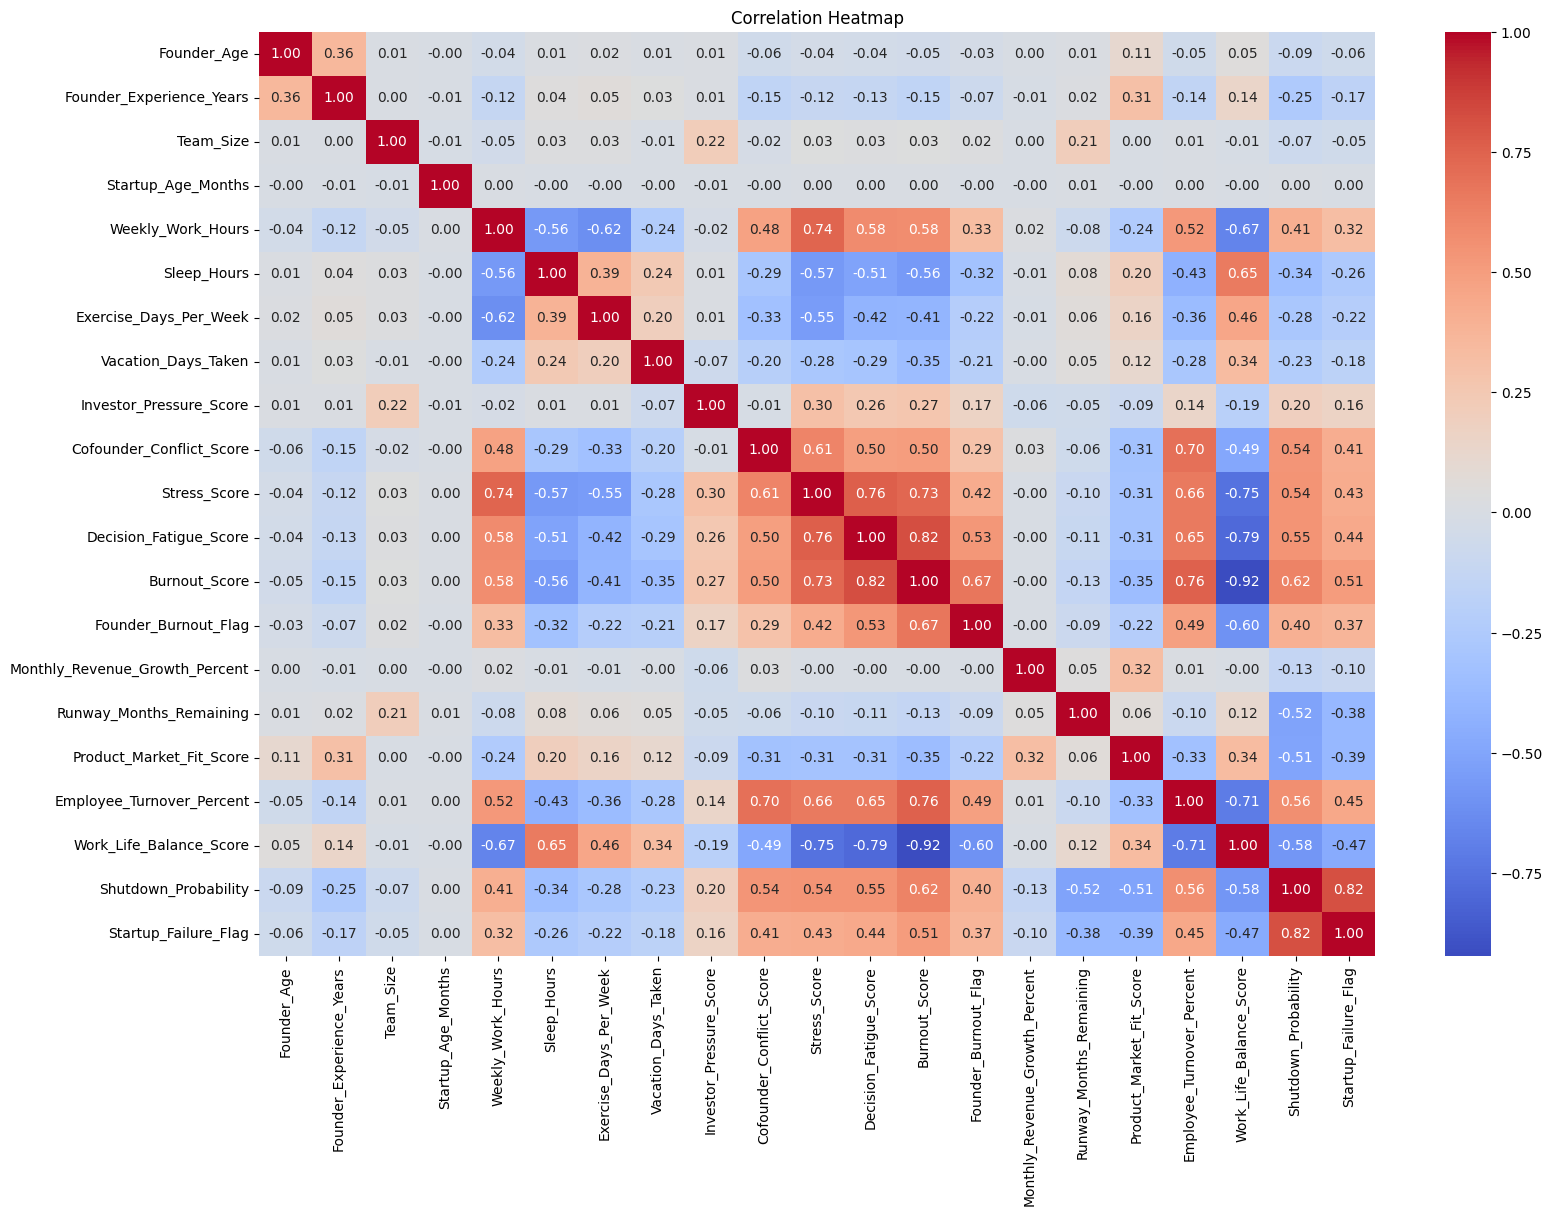

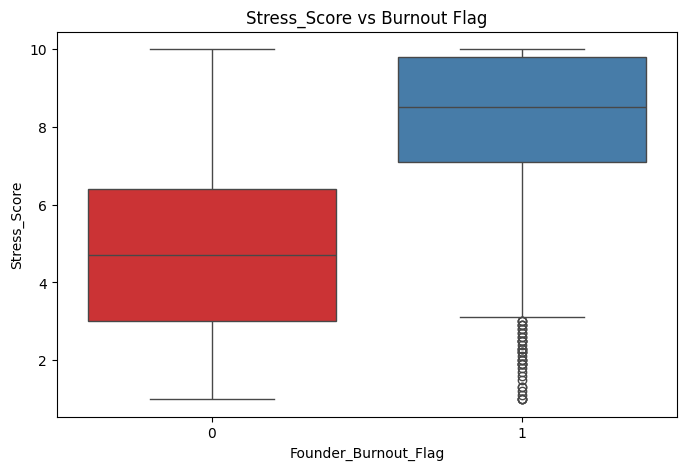

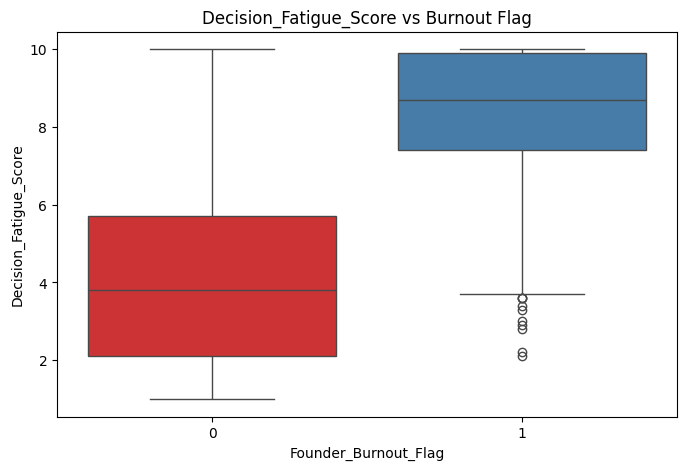

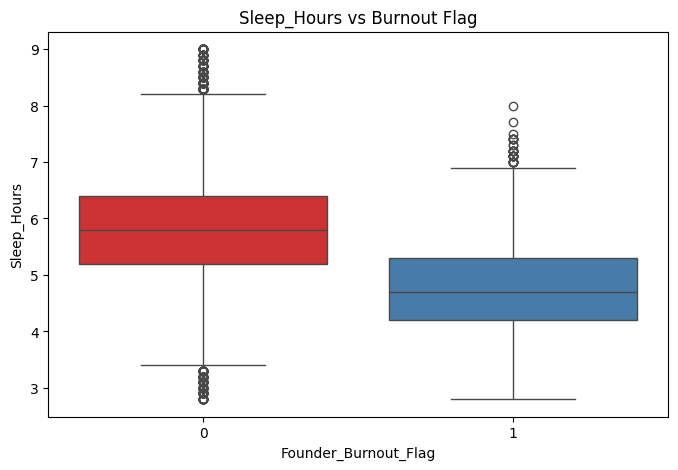

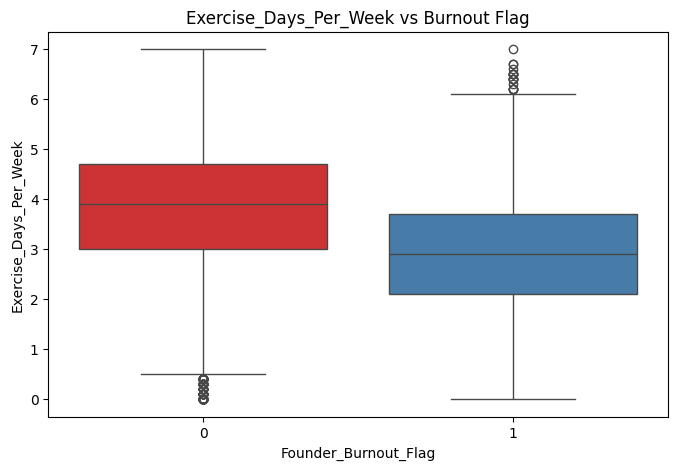

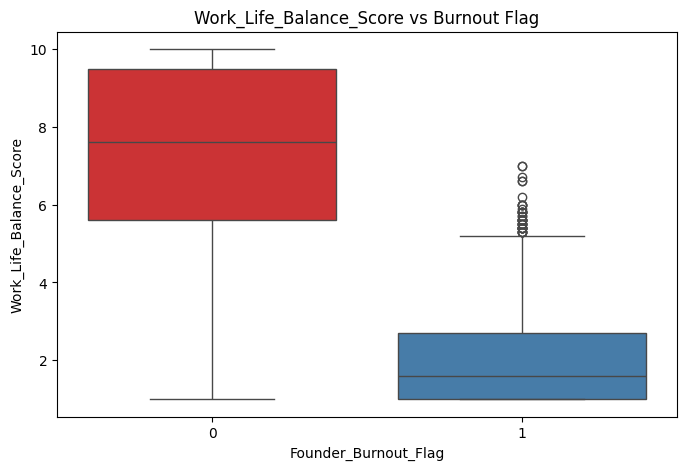

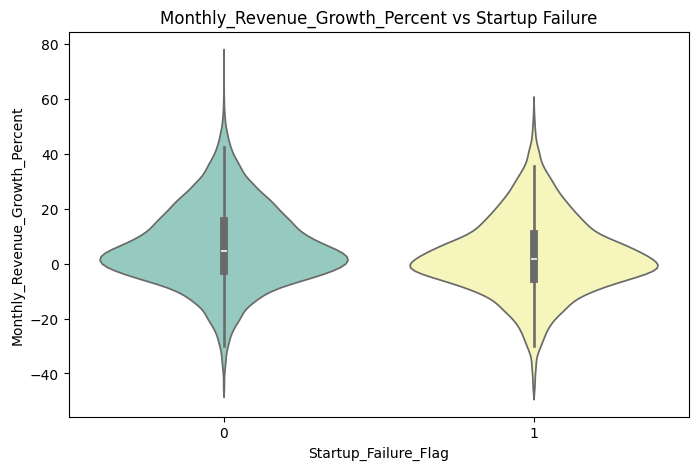

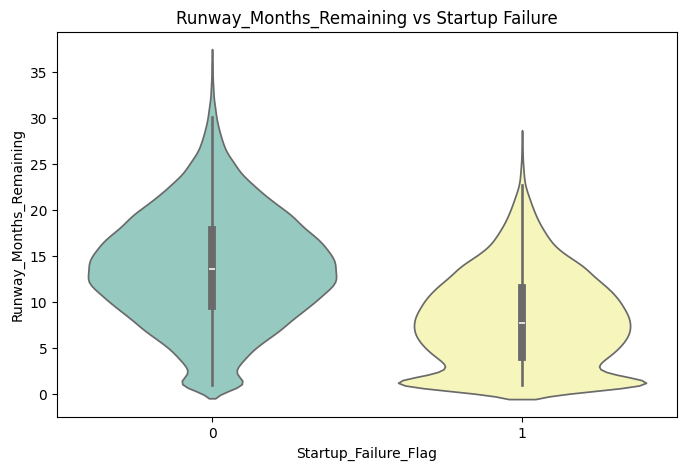

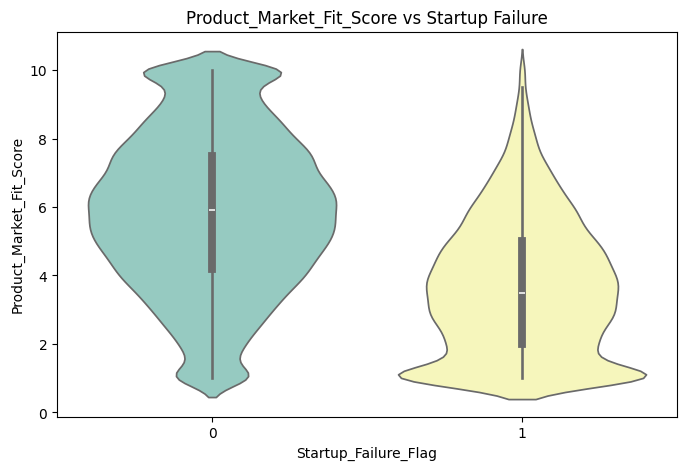

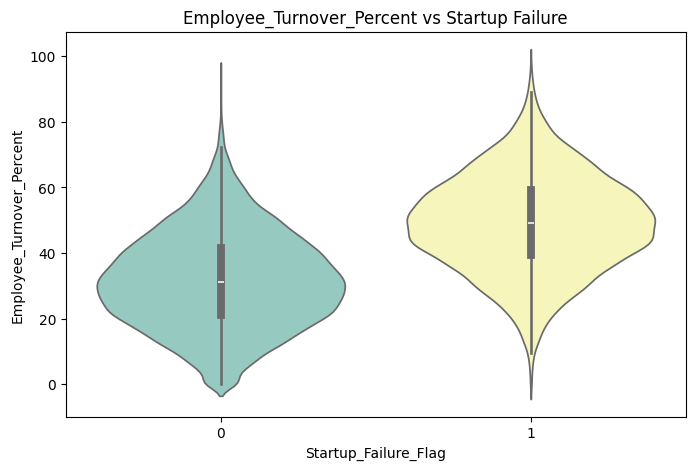

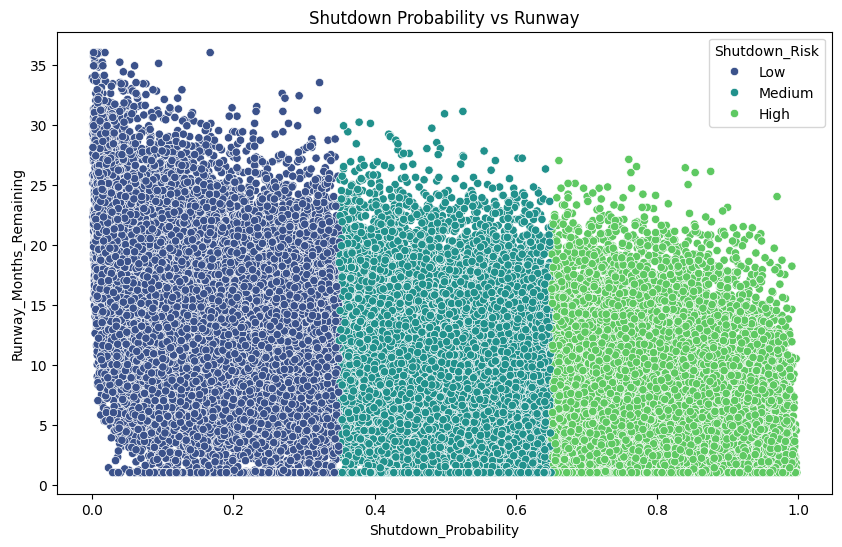

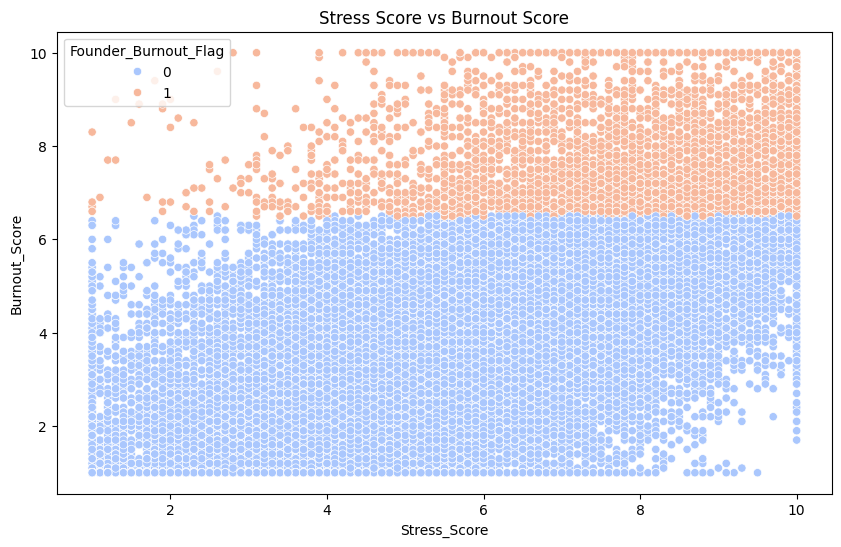

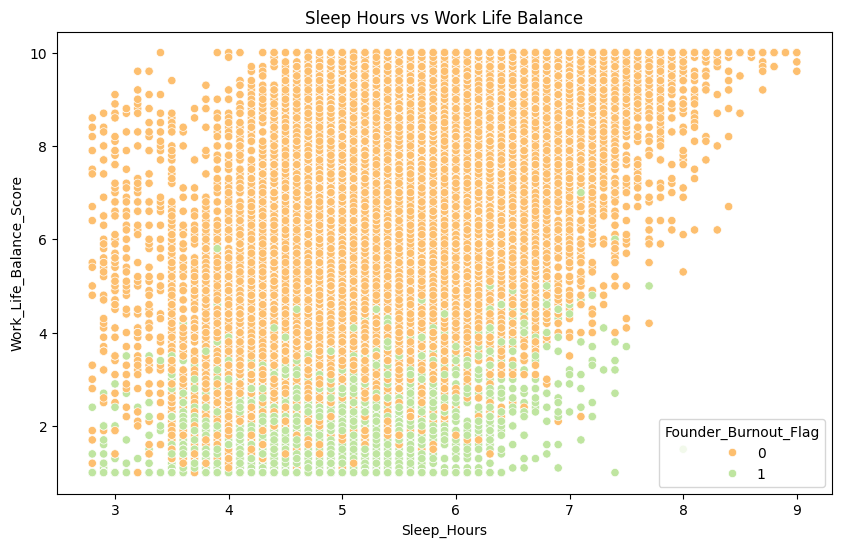

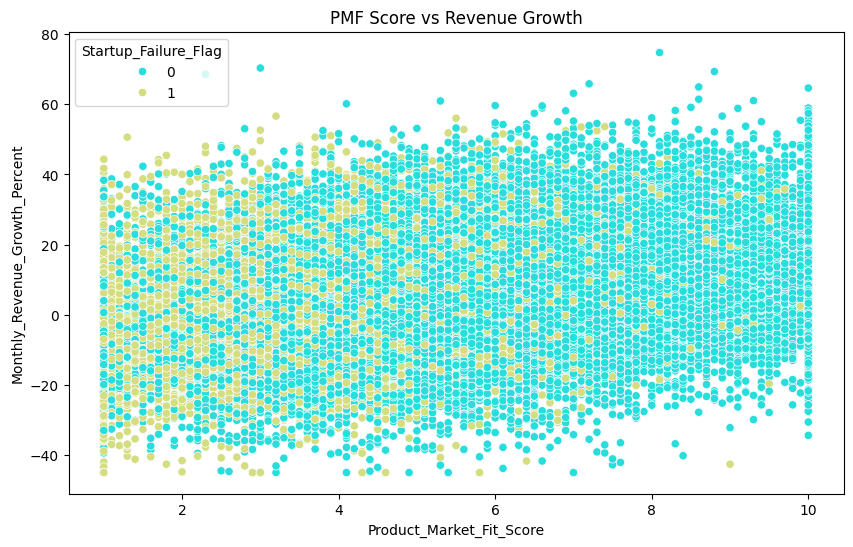

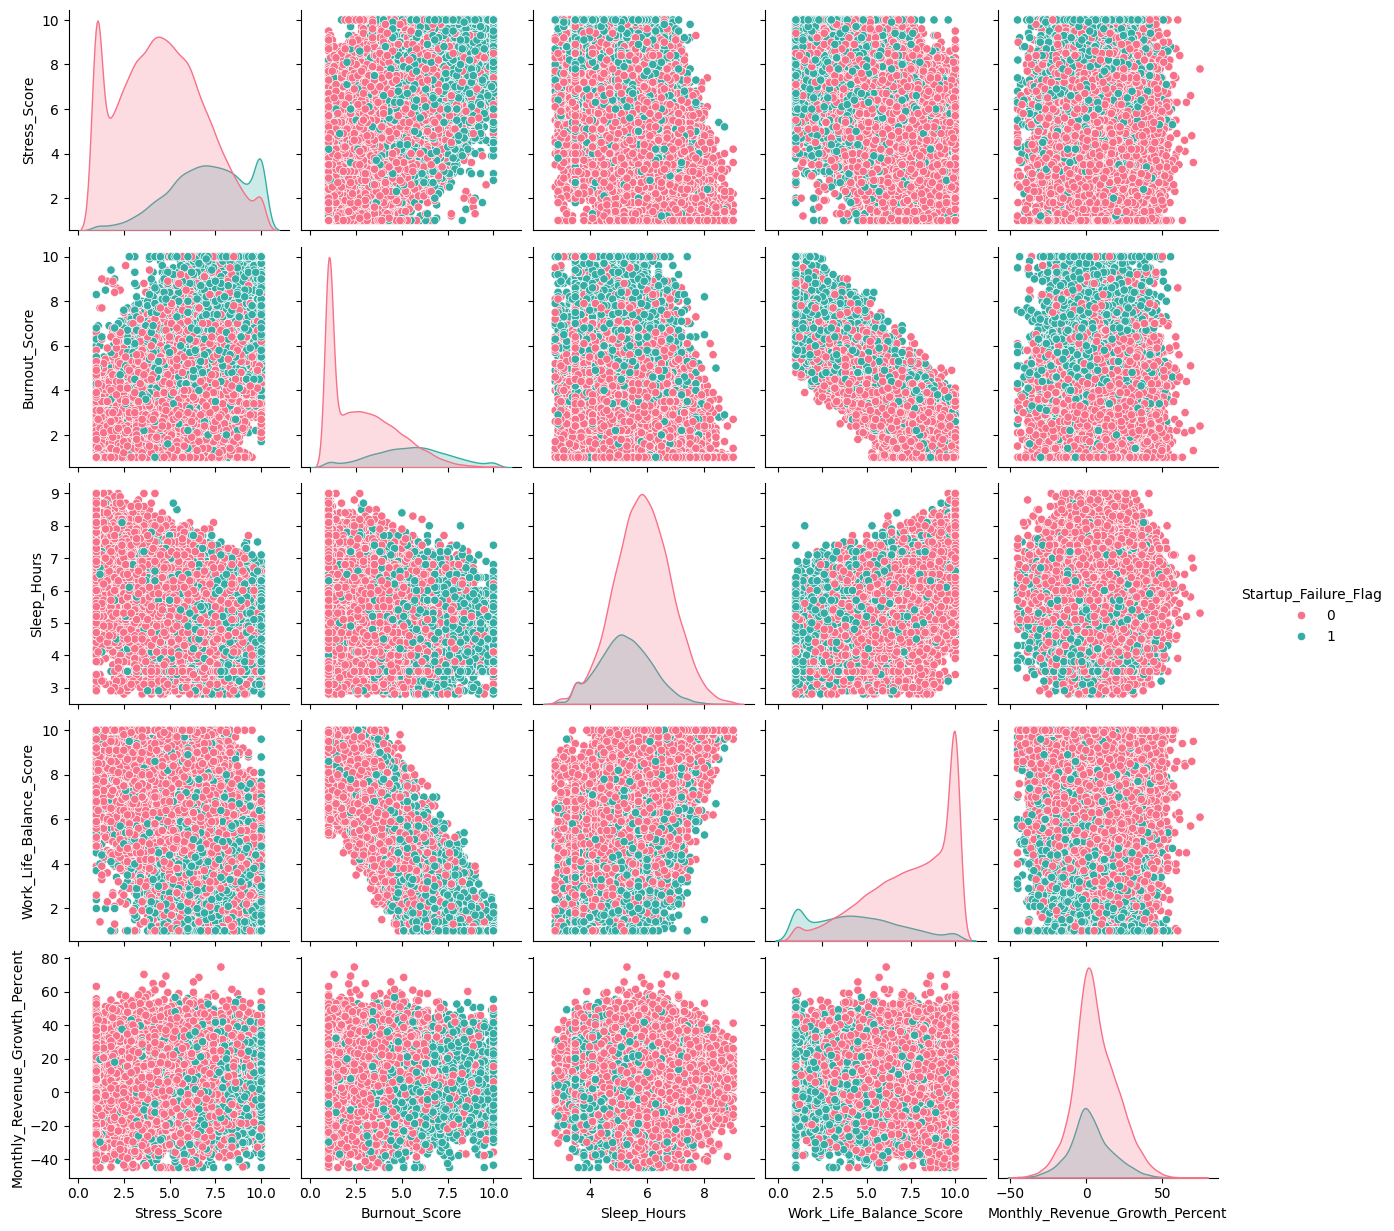

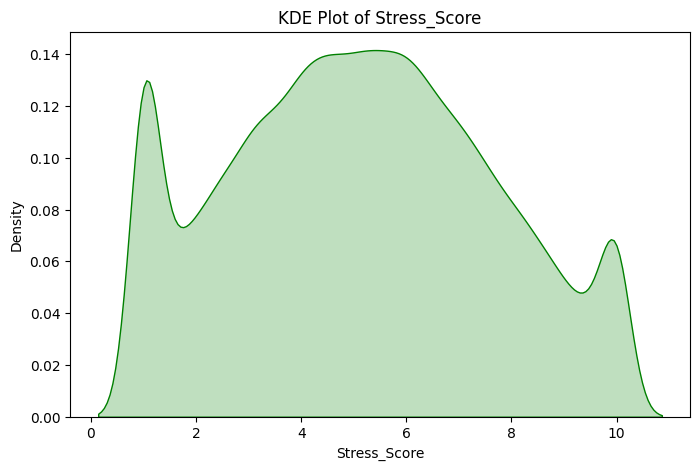

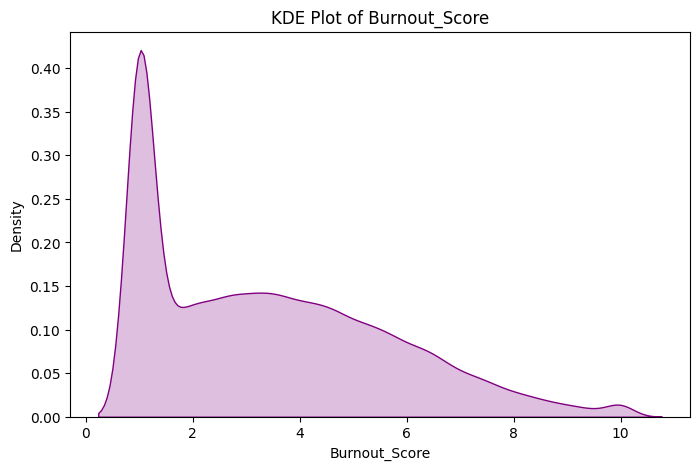

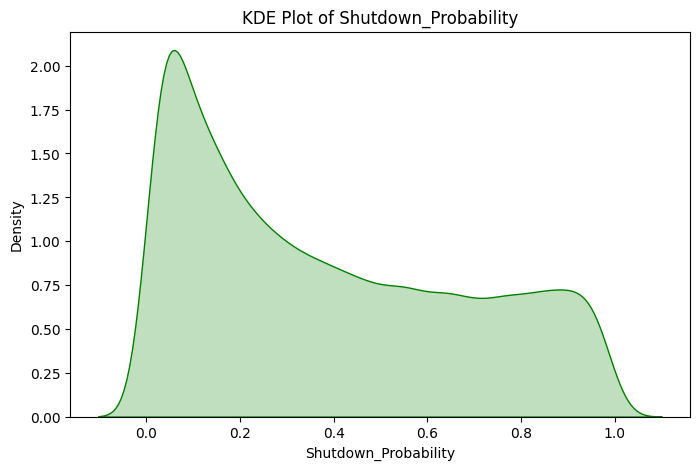

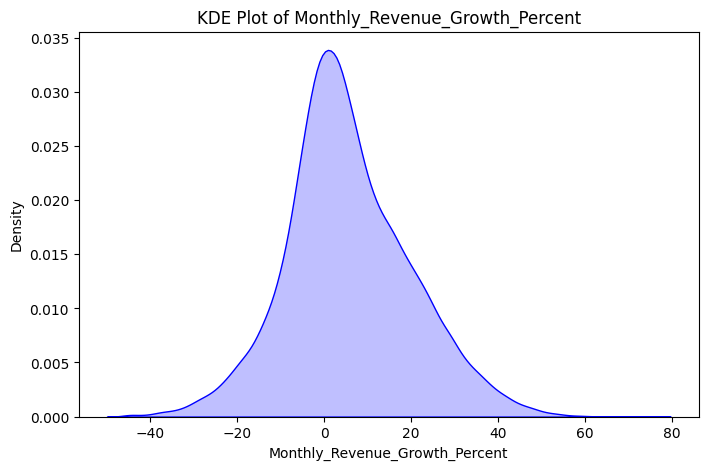

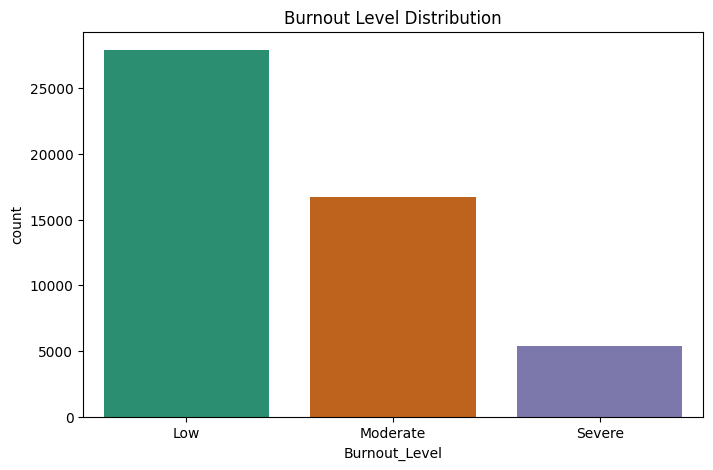

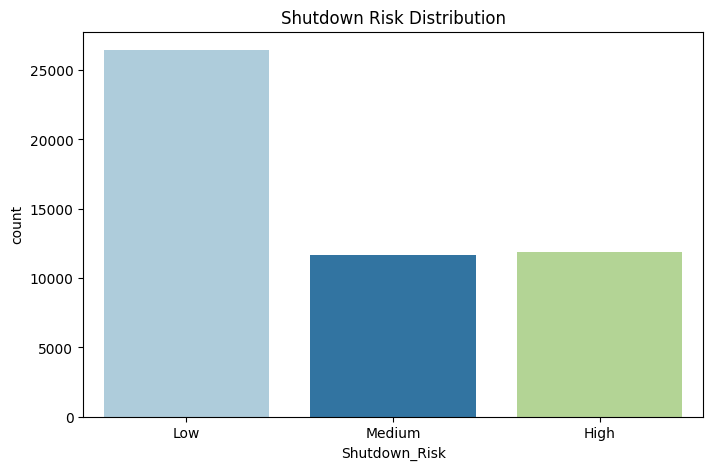

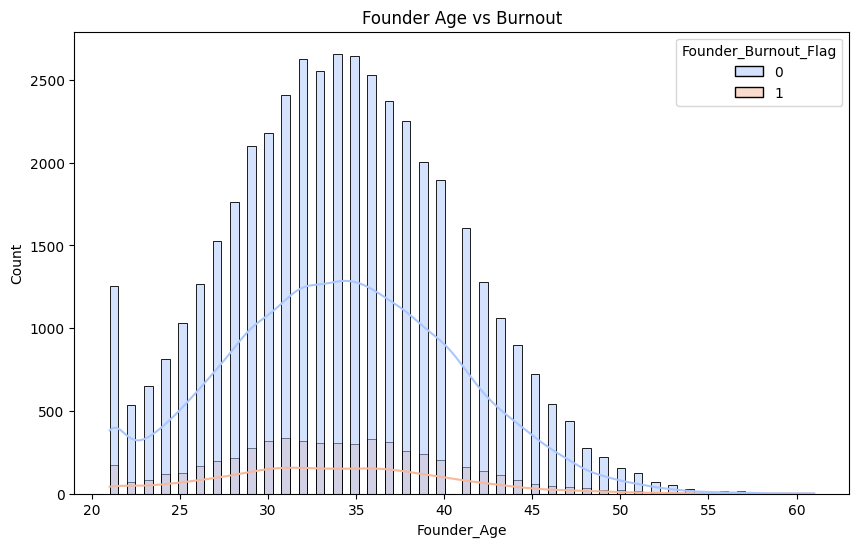

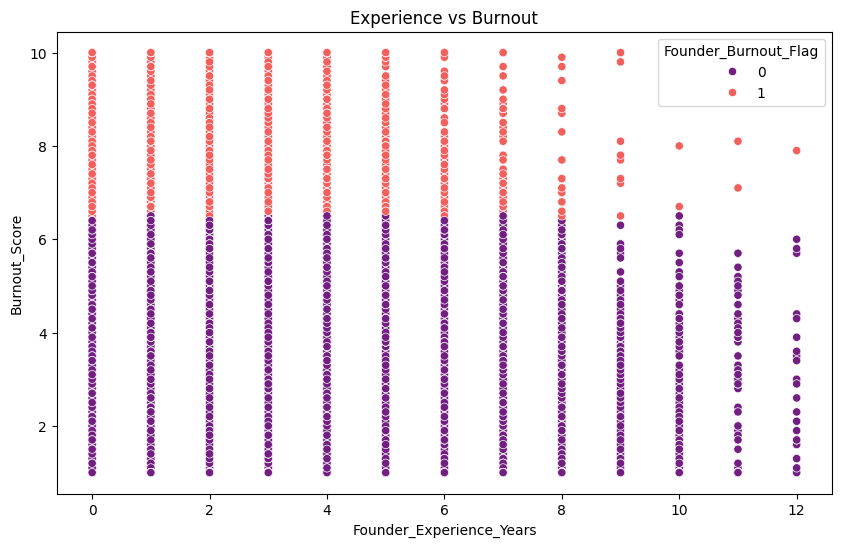

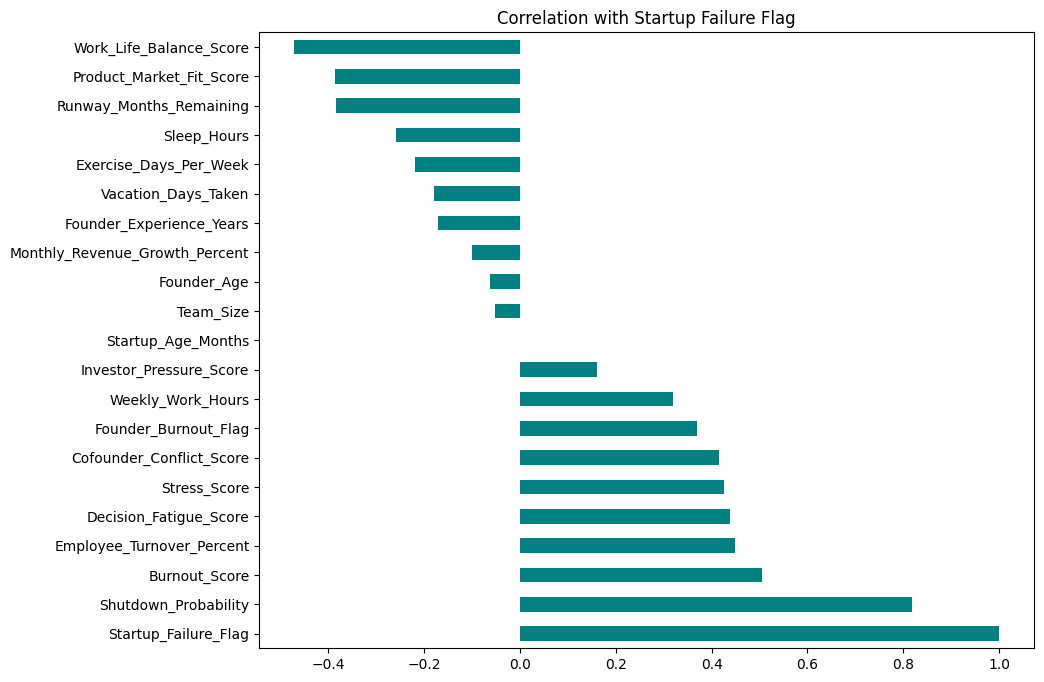

EDA Completed Successfully


In [15]:
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

# ============================================================
# MISSING VALUE VISUALIZATION
# ============================================================

plt.figure(figsize=(14,6))
sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)
plt.title("Missing Values Heatmap", fontsize=16)
plt.show()

# ============================================================
# TARGET VARIABLE DISTRIBUTION
# ============================================================

targets = [
    "Founder_Burnout_Flag",
    "Startup_Failure_Flag"
]

for target in targets:

    plt.figure(figsize=(7,5))

    sns.countplot(
        x=target,
        data=df,
        palette="Set2"
    )

    plt.title(f"{target} Distribution", fontsize=16)
    plt.show()

# ============================================================
# CATEGORICAL FEATURES
# ============================================================

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:

    plt.figure(figsize=(10,5))

    sns.countplot(
        y=col,
        data=df,
        palette="tab20"
    )

    plt.title(f"{col} Distribution", fontsize=15)

    plt.tight_layout()
    plt.show()

# ============================================================
# NUMERICAL FEATURES DISTRIBUTION
# ============================================================

num_cols = df.select_dtypes(
    exclude="object"
).columns

colors = [
    "red","blue","green","orange",
    "purple","brown","pink",
    "cyan","gold","magenta"
]

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True,
        color=colors[i % len(colors)],
        bins=30
    )

    plt.title(f"Distribution of {col}")

    plt.show()

# ============================================================
# BOXPLOTS FOR OUTLIERS
# ============================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=df[col],
        color=colors[i % len(colors)]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(18,12))

corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# ============================================================
# BURNOUT ANALYSIS
# ============================================================

burnout_features = [
    "Stress_Score",
    "Decision_Fatigue_Score",
    "Sleep_Hours",
    "Exercise_Days_Per_Week",
    "Work_Life_Balance_Score"
]

for col in burnout_features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x="Founder_Burnout_Flag",
        y=col,
        data=df,
        palette="Set1"
    )

    plt.title(f"{col} vs Burnout Flag")

    plt.show()

# ============================================================
# FAILURE ANALYSIS
# ============================================================

failure_features = [
    "Monthly_Revenue_Growth_Percent",
    "Runway_Months_Remaining",
    "Product_Market_Fit_Score",
    "Employee_Turnover_Percent"
]

for col in failure_features:

    plt.figure(figsize=(8,5))

    sns.violinplot(
        x="Startup_Failure_Flag",
        y=col,
        data=df,
        palette="Set3"
    )

    plt.title(f"{col} vs Startup Failure")

    plt.show()

# ============================================================
# SHUTDOWN RISK ANALYSIS
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Shutdown_Probability",
    y="Runway_Months_Remaining",
    hue="Shutdown_Risk",
    palette="viridis",
    data=df
)

plt.title("Shutdown Probability vs Runway")

plt.show()

# ============================================================
# STRESS VS BURNOUT SCORE
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Stress_Score",
    y="Burnout_Score",
    hue="Founder_Burnout_Flag",
    palette="coolwarm",
    data=df
)

plt.title("Stress Score vs Burnout Score")

plt.show()

# ============================================================
# WORK LIFE BALANCE
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Sleep_Hours",
    y="Work_Life_Balance_Score",
    hue="Founder_Burnout_Flag",
    palette="Spectral",
    data=df
)

plt.title("Sleep Hours vs Work Life Balance")

plt.show()

# ============================================================
# REVENUE GROWTH ANALYSIS
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Product_Market_Fit_Score",
    y="Monthly_Revenue_Growth_Percent",
    hue="Startup_Failure_Flag",
    palette="rainbow",
    data=df
)

plt.title("PMF Score vs Revenue Growth")

plt.show()

# ============================================================
# PAIRPLOT
# ============================================================

selected_features = [
    "Stress_Score",
    "Burnout_Score",
    "Sleep_Hours",
    "Work_Life_Balance_Score",
    "Monthly_Revenue_Growth_Percent",
    "Startup_Failure_Flag"
]

sns.pairplot(
    df[selected_features],
    hue="Startup_Failure_Flag",
    palette="husl"
)

plt.show()

# ============================================================
# KDE PLOTS
# ============================================================

kde_cols = [
    "Stress_Score",
    "Burnout_Score",
    "Shutdown_Probability",
    "Monthly_Revenue_Growth_Percent"
]

for col in kde_cols:

    plt.figure(figsize=(8,5))

    sns.kdeplot(
        data=df,
        x=col,
        fill=True,
        color=np.random.choice(
            ["red","blue","green","purple","orange"]
        )
    )

    plt.title(f"KDE Plot of {col}")

    plt.show()

# ============================================================
# BURNOUT LEVEL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x="Burnout_Level",
    data=df,
    palette="Dark2"
)

plt.title("Burnout Level Distribution")

plt.show()

# ============================================================
# SHUTDOWN RISK DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x="Shutdown_Risk",
    data=df,
    palette="Paired"
)

plt.title("Shutdown Risk Distribution")

plt.show()

# ============================================================
# FOUNDER AGE ANALYSIS
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Founder_Age",
    hue="Founder_Burnout_Flag",
    kde=True,
    palette="coolwarm"
)

plt.title("Founder Age vs Burnout")

plt.show()

# ============================================================
# EXPERIENCE ANALYSIS
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Founder_Experience_Years",
    y="Burnout_Score",
    hue="Founder_Burnout_Flag",
    palette="magma",
    data=df
)

plt.title("Experience vs Burnout")

plt.show()

# ============================================================
# FEATURE IMPORTANCE STYLE CORRELATION
# ============================================================

target_corr = corr["Startup_Failure_Flag"]\
    .sort_values(ascending=False)

plt.figure(figsize=(10,8))

target_corr.plot(
    kind="barh",
    color="teal"
)

plt.title(
    "Correlation with Startup Failure Flag"
)

plt.show()

print("EDA Completed Successfully")

## Feature engineering

In [16]:
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [17]:
TARGET = "Startup_Failure_Flag"

In [18]:
X = df.drop(TARGET, axis=1)

y = df[TARGET]

In [19]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Columns")
print(categorical_cols)

print("\nNumerical Columns")
print(numerical_cols)

Categorical Columns
['Founder_Type', 'Economic_Climate', 'Industry', 'Funding_Stage', 'Work_Mode', 'Burnout_Level', 'Seeks_Mental_Health_Support', 'Shutdown_Risk']

Numerical Columns
['Founder_Age', 'Founder_Experience_Years', 'Team_Size', 'Startup_Age_Months', 'Weekly_Work_Hours', 'Sleep_Hours', 'Exercise_Days_Per_Week', 'Vacation_Days_Taken', 'Investor_Pressure_Score', 'Cofounder_Conflict_Score', 'Stress_Score', 'Decision_Fatigue_Score', 'Burnout_Score', 'Founder_Burnout_Flag', 'Monthly_Revenue_Growth_Percent', 'Runway_Months_Remaining', 'Product_Market_Fit_Score', 'Employee_Turnover_Percent', 'Work_Life_Balance_Score', 'Shutdown_Probability']


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(40000, 28)
(10000, 28)


In [21]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_cols
        ),
        (
            "cat",
            categorical_transformer,
            categorical_cols
        )
    ]
)

In [22]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

In [23]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=500),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(
            probability=True
        )
}

In [24]:
results = []

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    pipe.fit(
        X_train,
        y_train
    )

    y_pred = pipe.predict(
        X_test
    )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    cv = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()

    results.append([
        name,
        acc,
        precision,
        recall,
        f1,
        cv
    ])

    print("\n")
    print("="*60)

    print(name)

    print("="*60)

    print(
        classification_report(
            y_test,
            y_pred
        )
    )



Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7627
           1       1.00      1.00      1.00      2373

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7627
           1       1.00      1.00      1.00      2373

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7627
           1       1.00      1.00      1.00      2373

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1

In [25]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "CV Accuracy"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall        F1  CV Accuracy
0  Logistic Regression     1.000   1.000000  1.000000  1.000000     1.000000
1        Decision Tree     1.000   1.000000  1.000000  1.000000     1.000000
2        Random Forest     1.000   1.000000  1.000000  1.000000     1.000000
3    Gradient Boosting     1.000   1.000000  1.000000  1.000000     1.000000
4          Extra Trees     1.000   1.000000  1.000000  1.000000     1.000000
6                  SVM     1.000   1.000000  1.000000  1.000000     1.000000
5                  KNN     0.991   0.986366  0.975558  0.980932     0.989725


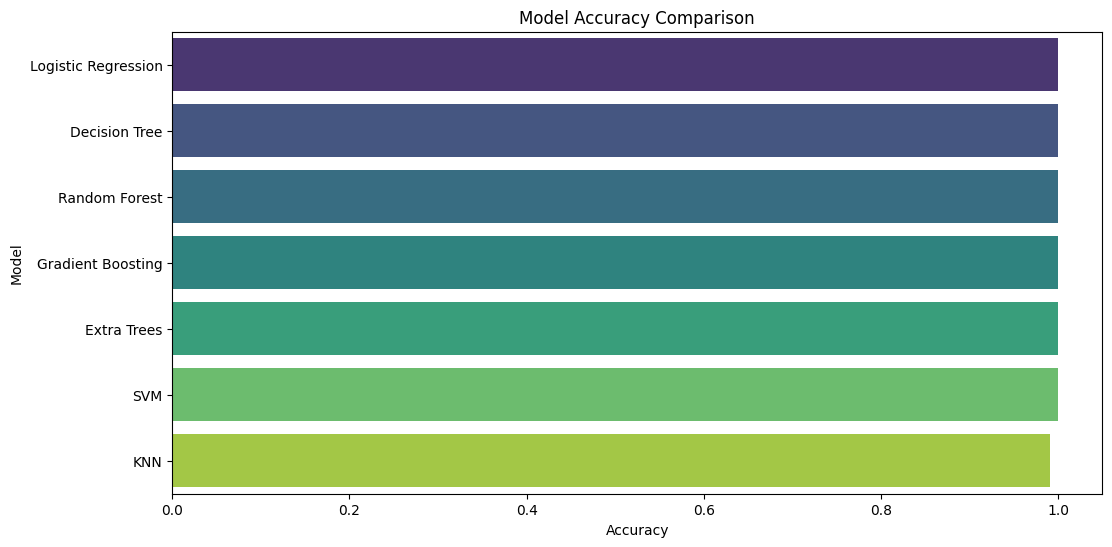

In [26]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title(
    "Model Accuracy Comparison"
)

plt.show()

In [27]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [28]:
best_model = models[best_model_name]

best_pipe = Pipeline(
    [
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            best_model
        )
    ]
)

best_pipe.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Founder_Age',
                                                   'Founder_Experience_Years',
                                                   'Team_Size',
                                                   'Startup_Age_Months',
                                                   'Weekly_Work_Hours',
                                                   'Sleep_Hours',
                                                   'Exercise_Days_Per_Week',
                                                   'Vacation_Days_Taken',
                                                   'Investor_Pressure_Score',
                                                   'Cofo...
                                                   'Work_Life_Balance_Score',
                                                   'Shutdown_Probability']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Founder_Type',
                                                   'Economic_Climate',
                                                   'Industry', 'Funding_Stage',
                                                   'Work_Mode', 'Burnout_Level',
                                                   'Seeks_Mental_Health_Support',
                                                   'Shutdown_Risk'])])),
                ('model', LogisticRegression(max_iter=500))])

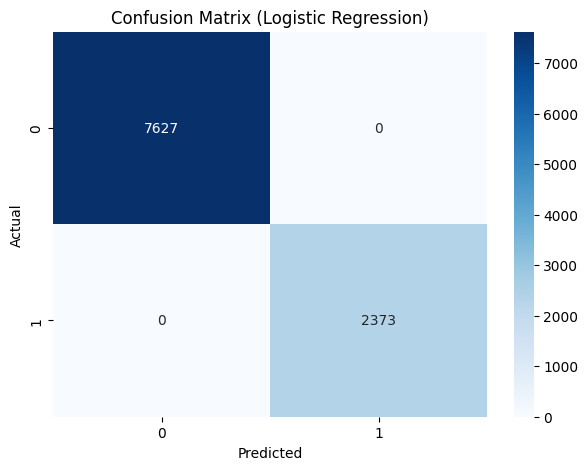

In [29]:
y_pred = best_pipe.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    f"Confusion Matrix ({best_model_name})"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

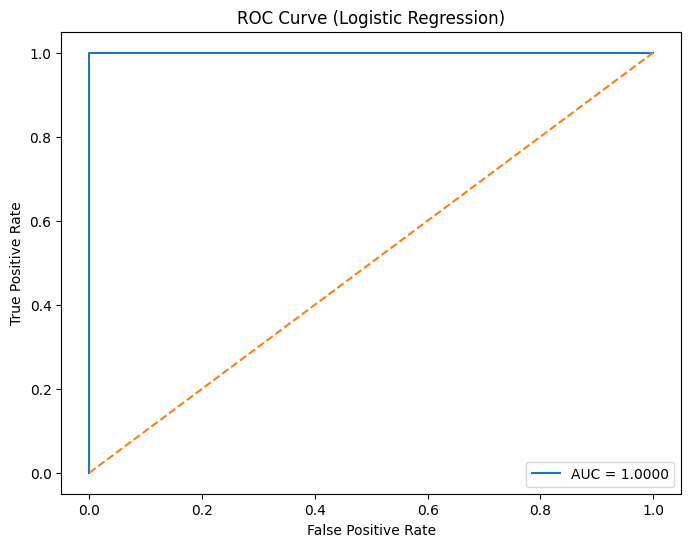

ROC-AUC Score: 1.0


In [30]:
y_prob = best_pipe.predict_proba(
    X_test
)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    f"ROC Curve ({best_model_name})"
)

plt.legend()

plt.show()

print(
    "ROC-AUC Score:",
    auc_score
)

In [31]:
if best_model_name in [
    "Random Forest",
    "Extra Trees",
    "Decision Tree"
]:

    transformed_cols = (
        numerical_cols +
        list(
            best_pipe.named_steps[
                "preprocessing"
            ]
            .named_transformers_["cat"]
            .named_steps["encoder"]
            .get_feature_names_out(
                categorical_cols
            )
        )
    )

    importance = (
        best_pipe.named_steps["model"]
        .feature_importances_
    )

    importance_df = pd.DataFrame(
        {
            "Feature": transformed_cols,
            "Importance": importance
        }
    )

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    print(
        importance_df.head(20)
    )

    plt.figure(
        figsize=(12,8)
    )

    sns.barplot(
        data=importance_df.head(20),
        x="Importance",
        y="Feature",
        palette="magma"
    )

    plt.title(
        "Top 20 Important Features"
    )

    plt.show()

## Thank you...pls upvote!!!!!!!!!!!!!!!!!!!!!!